# **1. Perkenalan Dataset**


## Deskripsi Dataset

Dataset ini memberikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas finansial, yang sangat ideal untuk eksplorasi dalam deteksi penipuan dan identifikasi anomali. Dataset ini terdiri dari 2.512 sampel data transaksi yang mencakup berbagai atribut transaksi, demografi pelanggan, dan pola penggunaan.

Setiap entri dalam dataset ini menyajikan informasi yang komprehensif tentang perilaku transaksi, sehingga memungkinkan analisis yang mendalam untuk aplikasi keamanan finansial dan deteksi penipuan.

### Fitur Utama:
- **TransactionID**: ID unik untuk setiap transaksi.
- **AccountID**: ID unik untuk setiap akun, dengan kemungkinan lebih dari satu transaksi per akun.
- **TransactionAmount**: Nilai transaksi dalam satuan mata uang, mulai dari pengeluaran harian hingga pembelian besar.
- **TransactionDate**: Tanggal dan waktu terjadinya transaksi.
- **TransactionType**: Jenis transaksi, dikategorikan sebagai 'Credit' atau 'Debit'.
- **Location**: Lokasi geografis transaksi, direpresentasikan dengan nama kota di AS.
- **DeviceID**: ID perangkat yang digunakan untuk melakukan transaksi.
- **IP Address**: Alamat IP yang terkait dengan transaksi, yang dapat berubah-ubah untuk beberapa akun.
- **MerchantID**: ID unik pedagang, menunjukkan pedagang yang sering digunakan maupun yang jarang oleh setiap akun.
- **AccountBalance**: Saldo akun setelah transaksi, dengan korelasi logis terhadap jenis dan nilai transaksi.
- **PreviousTransactionDate**: Waktu transaksi sebelumnya untuk akun yang sama, berguna untuk menghitung frekuensi transaksi.
- **Channel**: Saluran yang digunakan untuk melakukan transaksi (misalnya: Online, ATM, Cabang).
- **CustomerAge**: Usia pemegang akun, dengan pengelompokan logis berdasarkan pekerjaan.
- **CustomerOccupation**: Pekerjaan pemegang akun (misalnya: Dokter, Insinyur, Mahasiswa, Pensiunan) yang mencerminkan pola pendapatan.
- **TransactionDuration**: Lama waktu transaksi dalam detik, yang bervariasi tergantung jenis transaksi.
- **LoginAttempts**: Jumlah percobaan login sebelum transaksi, di mana nilai tinggi dapat mengindikasikan potensi anomali.

Dataset ini dirancang untuk digunakan oleh data scientist, analis keuangan, dan peneliti yang ingin menganalisis pola transaksi, mendeteksi aktivitas penipuan, dan membangun model prediktif dalam aplikasi keamanan finansial. Harap dicatat bahwa data ini disimulasikan dan tidak dimaksudkan sebagai sumber data utama untuk publikasi akademik.

### Sumber Dataset:
Dataset ini dapat diakses melalui Kaggle: [Bank Transaction Dataset for Fraud Detection](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection)


# **2. Import Library**

In [130]:
pip install summarytools

Note: you may need to restart the kernel to use updated packages.


In [131]:
import pandas as pd
import numpy as np
from summarytools import dfSummary
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import get_cmap
import folium
from geopy.geocoders import Nominatim
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# **3. Memuat Dataset**

In [132]:
df = pd.read_csv('/kaggle/input/bank-transaction-dataset-for-fraud-detection/bank_transactions_data_2.csv')
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


Data yang digunakan sudah sesuai dengan ketentuan, yakni:
1. **Dataset Awal Tidak Memiliki Label atau Kelas**
Dataset yang digunakan tidak memiliki label atau kelas sehingga dapat digunakan untuk tahapan unsupervised learning.

2. **Jumlah Baris Minimal**
Dataset yang dipilih harus memiliki minimal 1000 baris. Jumlah ini penting dalam memastikan bahwa dataset memiliki cukup banyak data untuk dilakukan analisis bermakna sehingga hasil model machine learning yang dibangun dapat diuji secara akurat dan menghasilkan wawasan lebih general.

3. **Jumlah kolom**
Minimal memiliki dua kolom yang digunakan untuk modelling, pastikan dataset tersebut mengandung data kategorikal atau data numerikal.

* Data Kategorikal: Variabel atau fitur yang terdiri dari kategori atau kelompok tertentu.
Contoh: jenis kelamin (laki-laki/perempuan), kategori produk (elektronik, pakaian, makanan).

* Data Numerikal: Nilai-nilai angka yang dapat diukur dan dianalisis. Contoh: usia, pendapatan, harga produk, atau jumlah unit yang terjual.

4. **Pembatasan Dataset yang Digunakan**
Untuk menjaga keragaman analisis dan menghindari repetisi, dataset yang digunakan dalam latihan clustering (customer segmentation) tidak boleh digunakan.

# **4. Exploratory Data Analysis (EDA)**

In [133]:
df.shape

(2512, 16)

In [134]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [136]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [137]:
df.describe(include='all')

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2512,2512,2512.000000,2512,2512,2512,2512,2512,2512,2512,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512
unique,2512,495,NaN,2512,2,43,681,592,100,3,NaN,4,NaN,NaN,NaN,360
top,TX000001,AC00362,NaN,2023-04-11 16:29:14,Debit,Fort Worth,D000697,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,1,12,NaN,1,1944,70,9,13,45,868,NaN,657,NaN,NaN,NaN,16
mean,NaN,NaN,297.593778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.673965,NaN,119.643312,1.124602,5114.302966,NaN
std,NaN,NaN,291.946243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.792198,NaN,69.963757,0.602662,3900.942499,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.885000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.370000,NaN
50%,NaN,NaN,211.140000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.500000,1.000000,4735.510000,NaN
75%,NaN,NaN,414.527500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7678.820000,NaN


In [138]:
df.nunique()

TransactionID              2512
AccountID                   495
TransactionAmount          2455
TransactionDate            2512
TransactionType               2
Location                     43
DeviceID                    681
IP Address                  592
MerchantID                  100
Channel                       3
CustomerAge                  63
CustomerOccupation            4
TransactionDuration         288
LoginAttempts                 5
AccountBalance             2510
PreviousTransactionDate     360
dtype: int64

In [139]:
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,TransactionID[object],1. TX0000012. TX0016793. TX0016724. TX0016735. TX0016746. TX0016757. TX0016768. TX0016779. TX00167810. TX00168011. other,"1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)1 (0.0%)2,502 (99.6%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAADQklEQVR4nO3cwWkbYRRG0TdCJPZGQghUQtKDisg2HauINGGkReJ44yyCS8gdmJxTwb+48BDMp+X9/X2gsFv7Afw/xEZGbGTERkZsZMRGRmxkxEZGbGTERma3LMvXZVme1n4I27ebmS8z83nth7B9zigZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkdnNzI+Z+b32Q9i+xb8YUXFGyYiNjHUVGesqMs4oGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZgxcyBi9knFEyYiNj8ELG4IWMM0pGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERsbghYzBCxlnlIzYyIiNjHUVGesqMs4oGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZ6yoy1lVknFEyYiNj8ELG4IWMM0pGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERsbghYzBCxlnlIzYyBi8kDF4IeOMkhEbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZ6yoy1lVknFEyYiNjXUXGuoqMM0pGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERsbghYzBCxlnlIzYyBi8kDF4IeOMkhEbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRMXghY/BCxhklIzYyYiNjXUXGuoqMM0pGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERsa6iox1FRlnlIzYyBi8kDF4IeOMkhEbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRMXghY/BCxhkls8zM88x8WvshbN7b/nw+fzscDqe1X8K2PR6Pl/3hcDhdr9dfx+Pxde0HsU33+/3pdrud9jMzx+Px9XK5/Fz7UWzasx8IZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZPYzfz8BWfshbNdHX8v5fP7u40n+tcfj8eKzcCpv1lVk/EAgIzYyYiMjNjJiIyM2MmIjIzYyYiPzB0WpV2yec8bJAAAAAElFTkSuQmCC"">",0(0.0%)
2,AccountID[object],1. AC003622. AC003633. AC002024. AC004605. AC002576. AC004567. AC003048. AC004809. AC0022510. AC0026711. other,"12 (0.5%)12 (0.5%)12 (0.5%)12 (0.5%)11 (0.4%)11 (0.4%)11 (0.4%)11 (0.4%)11 (0.4%)10 (0.4%)2,399 (95.5%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAADfUlEQVR4nO3cwWoTUQCG0ZsSit1MCIE8TB6iD+tD5G1CyCxs6SYujCtNFaxfMJ6zEtzM4mMyXu7v4nw+Dyg83PoB+H+IjYzYyIiNjNjIiI2M2MiIjYzYyCzGGE9jjHE+n19u/CzcueVms3keY4zFYvFZcPxND9M0radpWo8xHm/9MNw332xkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERmY5z/Px8ue3mz4Jd88GgczCf5lFxZuNjHUVGesqMo4+yIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIGLyQcS2cjMELGW82MgYvZAxeyDj6ICM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjY/BCxrVwMgYvZHyzkfEzSsa6iox1FRnfbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZKyryLgWTsa6iow3GxmDFzIGL2QcfZARGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkTF4IeNaOBmDFzLebGQMXsgYvJBx9EFGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZKyryNggkLGuIuPNRsa6iox1FRlHH2TERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZAxeyLgWTsbghYw3GxmDFzIGL2QcfZARGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkTF4IeNaOBmDFzK+2cj4GSVjXUXGuoqMbzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjLWVWRcCydjXUXGm42MwQsZgxcyjj7IiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MgYvJBxLZyMwQuZ7282V8L5KG/XfiWXm83m+bJBgD82z/Px2nhqOU3TerfbvaxWq9dbPBz343Q6fdrv9+vD4fA4xvgxtjHGWK1Wr9vt9kv+dNyjp2t/4ZyNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNzHKMb1dDbv0g/Pt+1dFynufjfr9fj3euhsDvugyofjqeci2cj3b1WrjBCxn/QCAjNjJiIyM2MmIjIzYyYiMjNjJiI/MVlHUQJ0ddGaUAAAAASUVORK5CYII="">",0(0.0%)
3,TransactionAmount[float64],Mean (sd) : 297.6 (291.9)min < med < max:0.3 < 211.1 < 1919.1IQR (CV) : 332.6 (1.0),"2,455 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAACZElEQVR4nO3cMW/aQBiH8fcKQQZaAyKCzStbB0aWfoN+2K4dI8HMt0BIVgDhhoCQu5SqUtIAd6H1//T8ZnxmeGR0yPe6siwNqLoP//sLAJeon/uAc65pZg3P9fdlWT55Xgv89maozrlmv9//mqZpz2fxzWbz6Jz7RqwIde6J2kjTtDeZTJ46nc7umoXX63UynU57eZ43zIxQEeTsT7+ZWafT2Q0Ggx8e6zc9rgFeYDMFCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCYQKCY

## Univariate Analysis

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


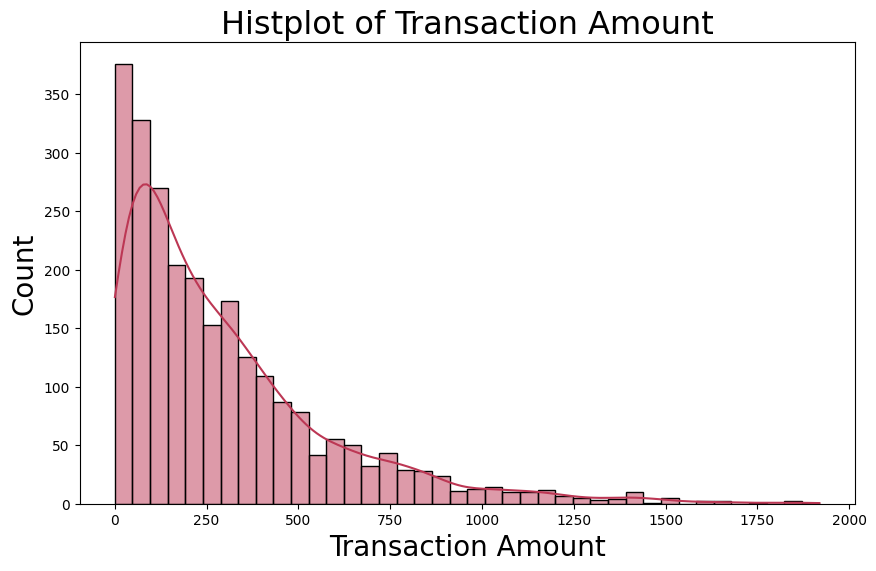

In [140]:
plt.figure(figsize=(10,6))
plt.xlabel("Transaction Amount", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.title("Histplot of Transaction Amount", fontsize=23)
sns.histplot(data=df, x="TransactionAmount", kde=True, color=sns.color_palette("inferno", n_colors=1)[0])
plt.show()

Berdasarkan histogram di atas, terlihat bahwa sebagian besar transaksi memiliki jumlah nominal yang relatif kecil. Distribusi menunjukkan pola yang condong ke kanan (right-skewed), di mana mayoritas transaksi berada pada kisaran di bawah 250 satuan mata uang. Jumlah transaksi kemudian menurun seiring dengan meningkatnya nilai transaksi, yang menunjukkan bahwa transaksi bernilai besar lebih jarang terjadi. Pola ini umum ditemukan dalam data keuangan, mencerminkan perilaku konsumen di mana transaksi kecil terjadi lebih sering, seperti pembelian sehari-hari, dibandingkan transaksi besar yang lebih jarang dan berisiko tinggi. Temuan ini penting untuk pengembangan model deteksi penipuan, karena anomali dapat lebih mudah terdeteksi pada transaksi yang tidak sesuai dengan distribusi umum.


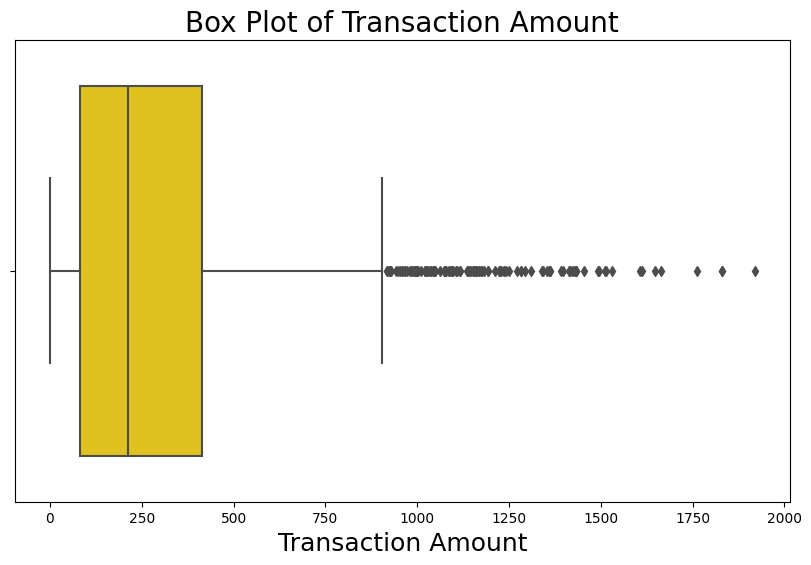

In [141]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['TransactionAmount'], color='gold')

plt.title('Box Plot of Transaction Amount', fontsize=20)
plt.xlabel('Transaction Amount', fontsize=18)

plt.show()

Box plot di atas menunjukkan distribusi nilai transaksi dengan lebih jelas terkait keberadaan outlier. Terlihat bahwa nilai transaksi sebagian besar berada di bawah 500 satuan mata uang, dengan nilai median sekitar 250. Rentang interkuartil (IQR) relatif sempit, menandakan bahwa mayoritas data terkonsentrasi pada kisaran rendah. Namun, terdapat banyak outlier di sisi kanan (nilai tinggi), menunjukkan adanya sejumlah transaksi dengan nilai yang jauh lebih besar dari mayoritas transaksi lainnya. Keberadaan outlier ini penting untuk diperhatikan dalam konteks deteksi anomali atau penipuan, karena transaksi dengan jumlah yang jauh di atas normal bisa menjadi indikator potensi aktivitas mencurigakan.

In [142]:
df['TransactionType'].value_counts()

TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64

In [143]:
debitcard_counts = df[df['TransactionType']=='Debit']['TransactionType'].count()
creditcard_counts = df[df['TransactionType']=='Credit']['TransactionType'].count()

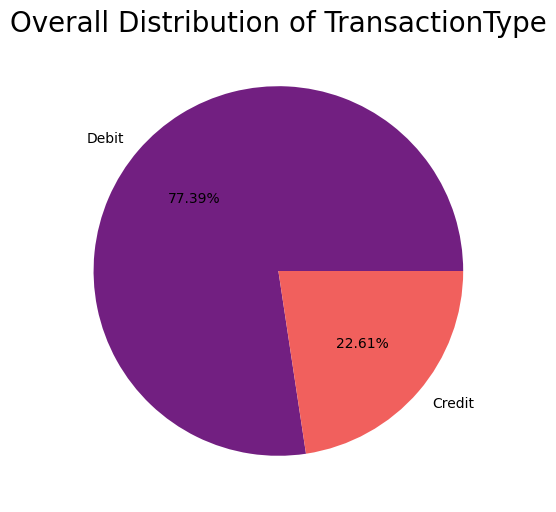

In [144]:
plt.figure(figsize=(10,6))
index_values = [debitcard_counts, creditcard_counts]
index_labels = ['Debit', 'Credit']
plt.pie(index_values, labels=index_labels, autopct='%2.2f%%', colors=sns.color_palette("magma", 2))
plt.title('Overall Distribution of TransactionType', fontsize=20)
plt.show()

Berdasarkan pie chart di atas, mayoritas transaksi dalam dataset ini merupakan transaksi bertipe **Debit**, yang mencakup sekitar **77.39%** dari seluruh transaksi. Sementara itu, transaksi **Credit** hanya mencakup sekitar **22.61%**. Distribusi ini mencerminkan kebiasaan umum pengguna dalam menggunakan rekening mereka lebih sering untuk melakukan pembayaran atau penarikan dana dibandingkan menerima dana. Proporsi ini penting untuk diperhatikan dalam konteks deteksi anomali, karena pergeseran pola distribusi yang signifikan dapat mengindikasikan aktivitas tidak biasa atau berpotensi penipuan.

In [145]:
location_counts = df['Location'].value_counts()
location_counts

Location
Fort Worth          70
Los Angeles         69
Oklahoma City       68
Charlotte           68
Tucson              67
Philadelphia        67
Omaha               65
Miami               64
Detroit             63
Houston             63
Memphis             63
Denver              62
Kansas City         61
Boston              61
Mesa                61
Atlanta             61
Seattle             61
Colorado Springs    60
Jacksonville        60
Fresno              60
Chicago             60
Austin              59
San Jose            59
Raleigh             59
San Antonio         59
San Diego           59
Indianapolis        58
New York            58
San Francisco       57
Nashville           55
Milwaukee           55
Las Vegas           55
Virginia Beach      55
Phoenix             55
Columbus            54
Sacramento          53
Baltimore           51
Louisville          51
Dallas              49
Washington          48
El Paso             46
Portland            42
Albuquerque         41
Na

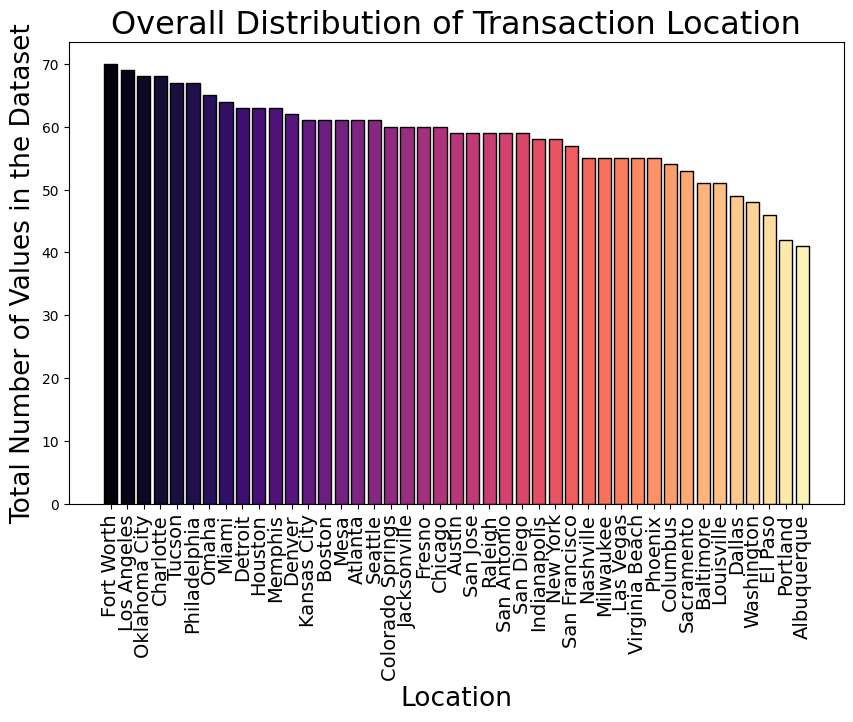

In [146]:
plt.figure(figsize=(10,6))
plt.bar(location_counts.index, location_counts.values, color=sns.color_palette("magma", len(location_counts.index)), edgecolor='black')
plt.xticks(location_counts.index, location_counts.index, rotation=90, fontsize=14)
plt.xlabel('Location', fontsize=19)
plt.ylabel('Total Number of Values in the Dataset', fontsize=19)
plt.title('Overall Distribution of Transaction Location', fontsize=23)
plt.show()

Visualisasi di atas menunjukkan sebaran jumlah transaksi berdasarkan lokasi (kota) dalam dataset. Kota **Fort Worth**, **Los Angeles**, dan **Oklahoma City** menempati posisi teratas dengan jumlah transaksi terbanyak, masing-masing lebih dari 65 transaksi. Sebaliknya, kota seperti **Albuquerque**, **Portland**, dan **El Paso** memiliki jumlah transaksi yang paling sedikit, sekitar 40 transaksi. Perbedaan ini dapat mencerminkan konsentrasi geografis aktivitas perbankan atau penggunaan sistem perbankan digital yang lebih tinggi di beberapa kota. Informasi ini penting dalam konteks analisis spasial untuk mendeteksi anomali geografis atau pola penipuan yang terlokalisasi.

In [147]:
df['DeviceID'].value_counts()

DeviceID
D000697    9
D000203    9
D000548    9
D000663    9
D000142    9
          ..
D000130    1
D000298    1
D000087    1
D000071    1
D000543    1
Name: count, Length: 681, dtype: int64

In [148]:
df['Channel'].value_counts()

Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64

In [149]:
branch_counts = df[df['Channel']=='Branch']['Channel'].count()
atm_counts = df[df['Channel']=='ATM']['Channel'].count()
online_counts = df[df['Channel']=='Online']['Channel'].count()

branch_counts, atm_counts, online_counts

(868, 833, 811)

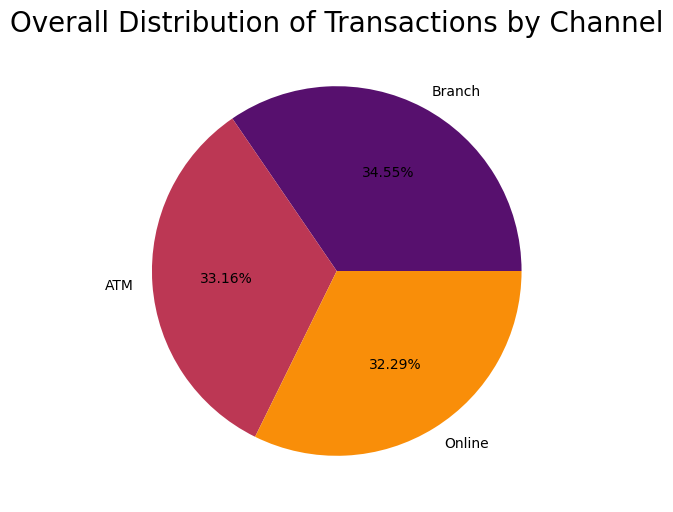

In [150]:
plt.figure(figsize=(10, 6))
index_values = [branch_counts, atm_counts, online_counts]
index_labels = ['Branch', 'ATM', 'Online']
plt.pie(index_values, labels=index_labels, autopct='%2.2f%%', colors=sns.color_palette("inferno", 3))
plt.title('Overall Distribution of Transactions by Channel', fontsize=20)
plt.show()

Pie chart di atas menunjukkan bahwa transaksi dilakukan secara relatif merata melalui ketiga channel utama: **Branch (34.55%)**, **ATM (33.16%)**, dan **Online (32.29%)**. Meskipun perbedaannya tidak terlalu mencolok, cabang fisik (Branch) sedikit mendominasi dalam jumlah transaksi. Temuan ini mengindikasikan bahwa meskipun layanan digital seperti ATM dan Online telah banyak digunakan, interaksi langsung melalui cabang masih memegang peranan penting dalam aktivitas perbankan. Analisis berdasarkan channel ini bermanfaat dalam mengidentifikasi saluran dengan risiko fraud lebih tinggi dan merancang strategi mitigasi risiko yang sesuai.

TransactionDay
2023-01-02    19
2023-01-03     9
2023-01-04     4
2023-01-05     8
2023-01-06     7
              ..
2023-12-26     5
2023-12-27     4
2023-12-28     7
2023-12-29     9
2024-01-01    13
Length: 261, dtype: int64


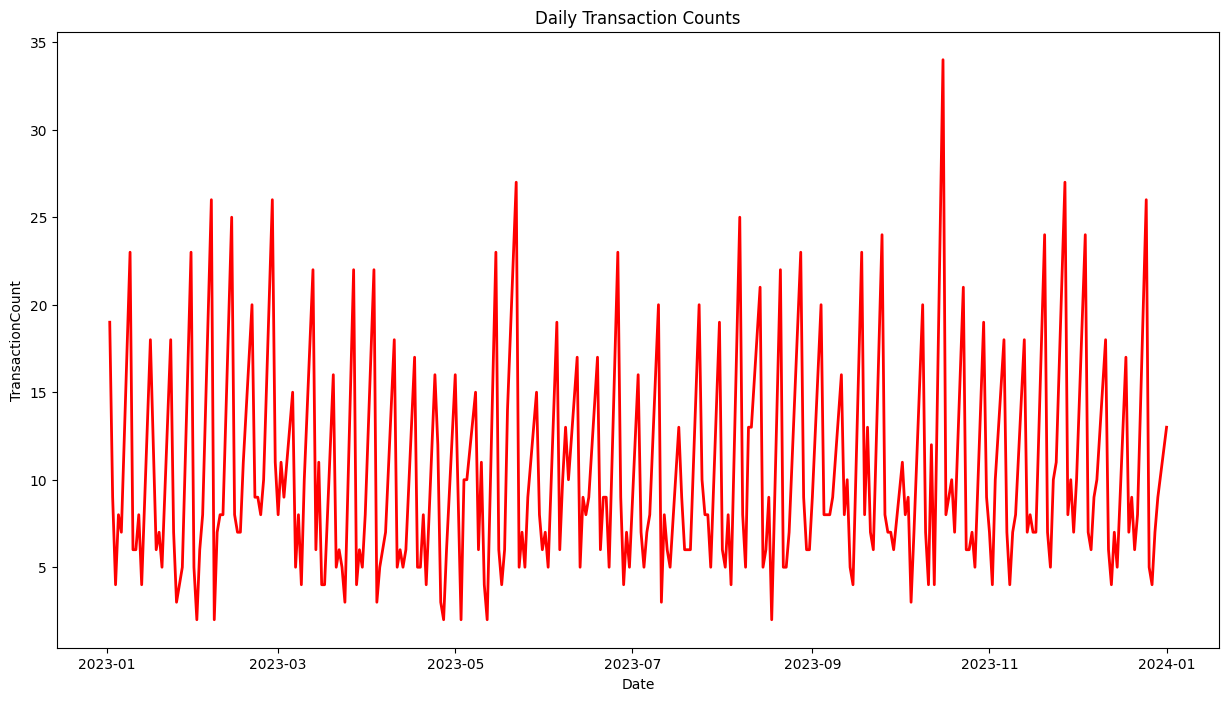

In [151]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['TransactionDay'] = df['TransactionDate'].dt.date
daily_counts = df.groupby('TransactionDay').size() 
print(daily_counts)
plt.figure(figsize=(15,8))
daily_counts.plot(title='Daily Transaction Counts', color='red', linewidth=2)
plt.xlabel('Date')
plt.ylabel('TransactionCount')
plt.show()


Grafik di atas menunjukkan fluktuasi jumlah transaksi harian sepanjang tahun 2023. Terlihat bahwa jumlah transaksi per hari sangat bervariasi, dengan rentang antara sekitar 2 hingga lebih dari 30 transaksi per hari. Tidak ada tren musiman atau pola jangka panjang yang jelas, namun terdapat lonjakan-lonjakan tertentu yang signifikan, seperti di bulan Oktober dan November. Pola yang fluktuatif ini bisa mengindikasikan adanya periode aktivitas tinggi yang perlu dianalisis lebih lanjut untuk kemungkinan adanya kejadian khusus (event-driven), promosi, atau potensi aktivitas abnormal. Analisis lebih lanjut dapat dilakukan dengan mengelompokkan data per minggu atau bulan untuk mengidentifikasi pola periodik yang tersembunyi.

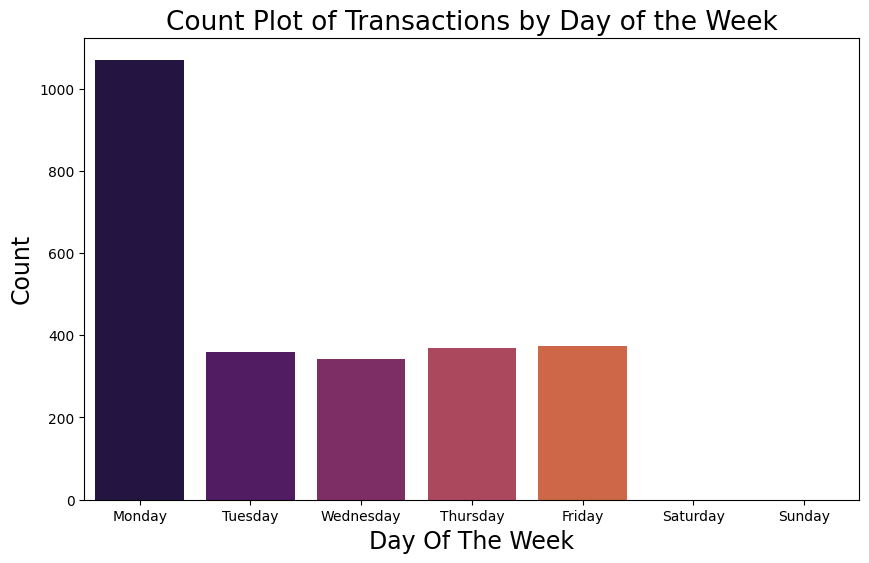

In [152]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['DayOfWeek'] = df['TransactionDate'].dt.day_name()
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='DayOfWeek', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette=sns.color_palette("inferno", 7))
plt.title('Count Plot of Transactions by Day of the Week', fontsize=19)
plt.xlabel('Day Of The Week', fontsize=17)
plt.ylabel('Count', fontsize=17)
plt.show()

Plot di atas menunjukkan distribusi transaksi berdasarkan hari dalam seminggu. Terlihat bahwa **Senin (Monday)** secara signifikan memiliki jumlah transaksi terbanyak, melebihi 1.000 transaksi. Sementara itu, transaksi pada hari **Selasa hingga Jumat** relatif stabil dan jauh lebih rendah dari Senin. Menariknya, tidak terdapat transaksi yang tercatat pada **Sabtu dan Minggu**, yang kemungkinan mencerminkan tidak adanya aktivitas perbankan selama akhir pekan, atau sistem pencatatan transaksi yang hanya aktif pada hari kerja. Pola ini dapat digunakan untuk mendeteksi anomali jika muncul transaksi dalam jumlah besar pada akhir pekan, yang secara historis tidak umum terjadi.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


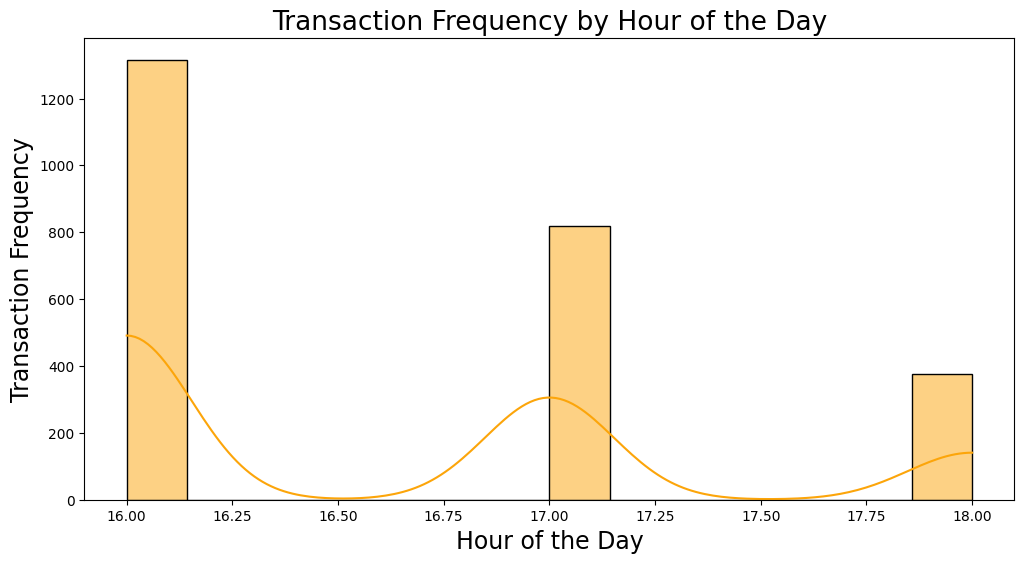

In [153]:
df['Hour'] = df['TransactionDate'].dt.hour
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Hour', kde=True, color=sns.color_palette("inferno", as_cmap=True)(0.8))
plt.title('Transaction Frequency by Hour of the Day', fontsize=19)
plt.xlabel('Hour of the Day', fontsize=17)
plt.ylabel('Transaction Frequency', fontsize=17)
plt.show()

Grafik di atas menunjukkan bahwa frekuensi transaksi sangat terkonsentrasi pada waktu tertentu, terutama pada pukul **16:00**, yang mencatat jumlah transaksi tertinggi, diikuti oleh pukul **17:00**, dan lebih sedikit lagi pada pukul **18:00**. Pola ini mengindikasikan adanya lonjakan aktivitas transaksi di sore hari, kemungkinan terkait dengan jam operasional kantor atau kebiasaan pengguna dalam menyelesaikan transaksi menjelang akhir hari kerja. Lonjakan semacam ini bisa menjadi indikator penting dalam perencanaan kapasitas sistem, serta menjadi waktu yang sensitif untuk pengawasan keamanan transaksi.


In [154]:
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
df['Time_Gap'] = (df['TransactionDate'] - df['PreviousTransactionDate'])
df['Time_Gap']

0      -573 days +08:21:06
1      -496 days +08:34:44
2      -483 days +10:09:04
3      -549 days +08:23:05
4      -385 days +09:44:45
               ...        
2507   -558 days +08:58:07
2508   -593 days +09:25:06
2509   -441 days +09:00:11
2510   -619 days +08:12:24
2511   -629 days +08:13:34
Name: Time_Gap, Length: 2512, dtype: timedelta64[ns]

In [155]:
df['CustomerAge'].value_counts()

CustomerAge
27    87
26    86
25    73
28    68
21    64
      ..
73    19
70    19
80    17
74    16
71    16
Name: count, Length: 63, dtype: int64

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


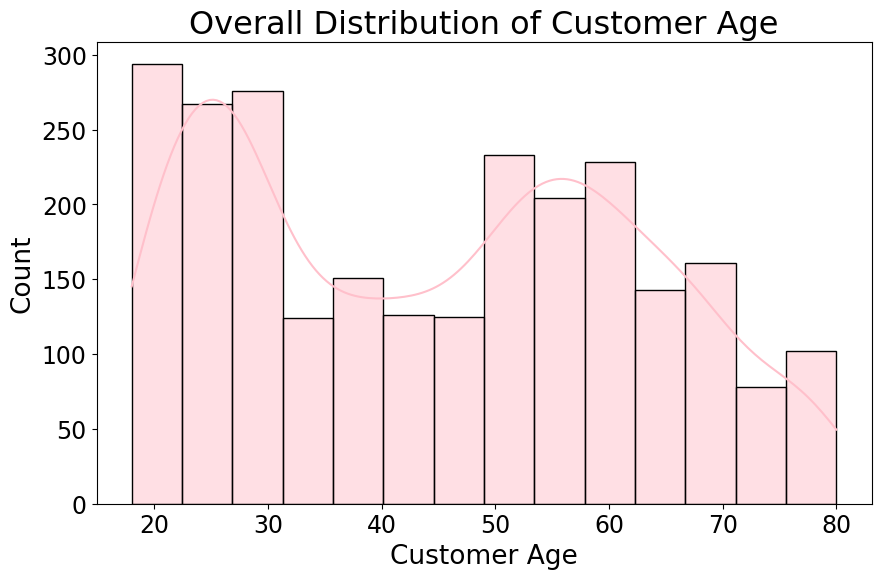

In [156]:
plt.figure(figsize=(10,6))
plt.xlabel('Customer Age', fontsize=19)
plt.ylabel('Count', fontsize=19)
plt.yticks(fontsize=17)
plt.xticks(fontsize=17)
plt.title('Overall Distribution of Customer Age', fontsize=23)
sns.histplot(data = df, x=df['CustomerAge'], kde=True, color='pink')

plt.show()

Histogram di atas menunjukkan bahwa usia pelanggan dalam dataset tersebar dari usia 18 hingga sekitar 80 tahun, dengan dua kelompok usia yang menonjol. Kelompok usia **20–30 tahun** merupakan segmen terbanyak, yang kemungkinan besar terdiri dari pengguna aktif digital dan pekerja muda. Selain itu, terdapat lonjakan kedua pada kelompok usia **50–60 tahun**, yang bisa mencerminkan kelompok pelanggan mapan dengan aktivitas finansial yang tinggi. Distribusi ini mengindikasikan adanya dua segmen utama dalam basis pelanggan: generasi muda yang aktif secara digital dan generasi paruh baya yang mungkin melakukan transaksi dalam jumlah lebih besar. Segmentasi ini penting untuk analisis perilaku dan pengembangan strategi deteksi penipuan yang disesuaikan berdasarkan usia.

In [157]:
merchant_counts = df['MerchantID'].value_counts()
merchant_counts

MerchantID
M026    45
M066    34
M065    33
M013    33
M014    33
        ..
M006    16
M077    16
M069    15
M072    15
M079    13
Name: count, Length: 100, dtype: int64

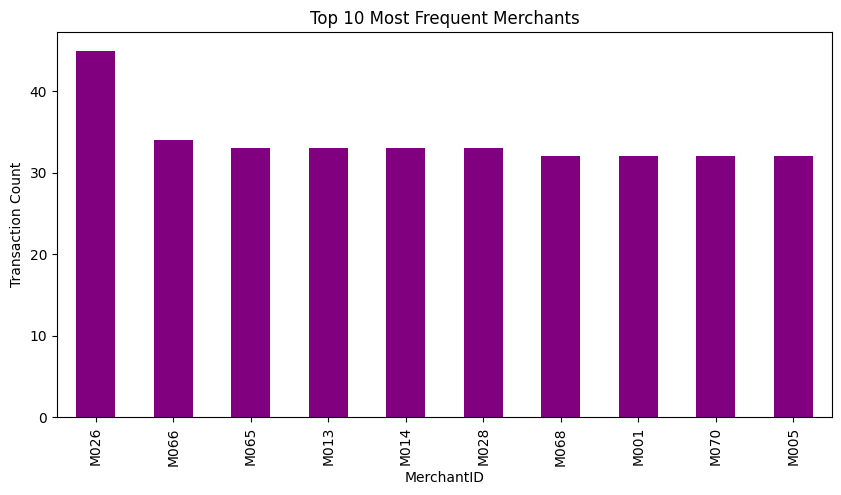

In [158]:
merchant_counts_top10 = df['MerchantID'].value_counts().head(10)
plt.figure(figsize=(10, 5))
merchant_counts_top10.plot(kind='bar', color='purple') 
plt.title("Top 10 Most Frequent Merchants")
plt.xlabel("MerchantID")
plt.ylabel("Transaction Count")
plt.show()

Grafik di atas menampilkan 10 merchant dengan jumlah transaksi terbanyak dalam dataset. **Merchant M026** menempati posisi teratas dengan jumlah transaksi mencapai lebih dari 45, secara signifikan lebih tinggi dibandingkan merchant lainnya yang memiliki jumlah transaksi serupa di kisaran 32–34 transaksi. Dominasi M026 ini dapat mengindikasikan merchant yang sangat populer atau sering digunakan oleh banyak pengguna, namun juga bisa menjadi kandidat untuk analisis lebih lanjut terkait potensi pola penipuan jika ditemukan aktivitas tidak wajar. Pemantauan terhadap merchant dengan frekuensi tinggi penting untuk mendeteksi anomali atau konsentrasi risiko transaksi.

In [159]:
customer_occupation_counts = df['CustomerOccupation'].value_counts()
customer_occupation_counts

CustomerOccupation
Student     657
Doctor      631
Engineer    625
Retired     599
Name: count, dtype: int64

<ipython-input-160-b5f372a157d8>:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma')


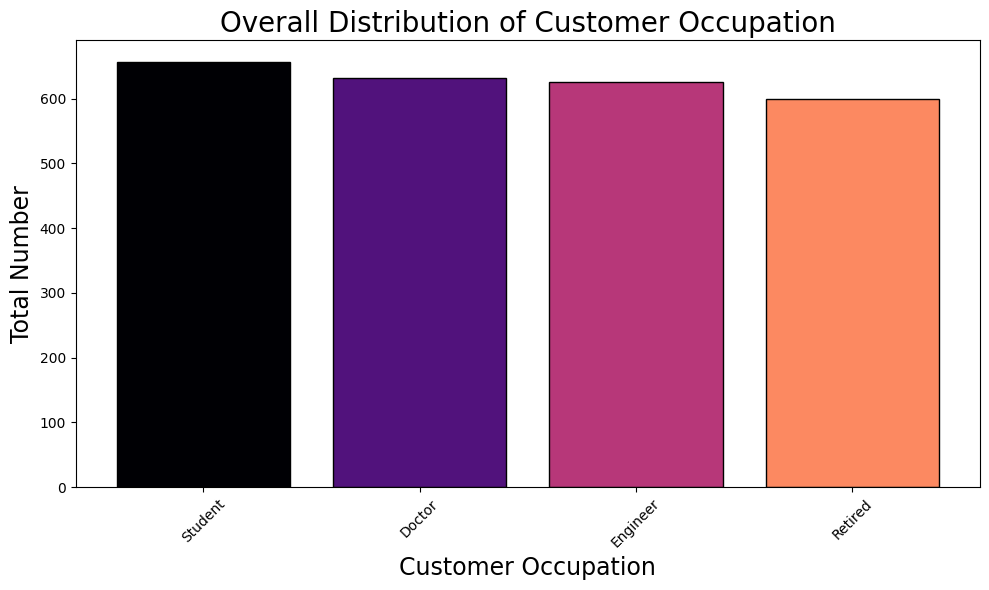

In [160]:
plt.figure(figsize=(10,6))

cmap = get_cmap('magma')
colors = [cmap(i / len(customer_occupation_counts)) for i in range(len(customer_occupation_counts))]
plt.bar(customer_occupation_counts.index, customer_occupation_counts.values, color=colors, edgecolor='black')
plt.xlabel('Customer Occupation', fontsize=17)
plt.ylabel('Total Number', fontsize=17)
plt.title('Overall Distribution of Customer Occupation', fontsize=20)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

Grafik di atas memperlihatkan distribusi jumlah pelanggan berdasarkan kategori pekerjaan. Kelompok **Student** merupakan kategori terbanyak, diikuti secara berurutan oleh **Doctor**, **Engineer**, dan **Retired**. Meskipun perbedaannya tidak terlalu besar, dominasi pelanggan dari kalangan pelajar menunjukkan bahwa segmen muda dan aktif secara digital memiliki representasi yang tinggi dalam data ini. Hal ini bisa berdampak pada pola transaksi yang cenderung lebih kecil namun lebih sering. Sementara itu, kelompok **Retired** sebagai kategori dengan jumlah terendah masih menunjukkan partisipasi yang signifikan, yang dapat dianalisis lebih lanjut terkait preferensi channel atau nilai transaksi yang mungkin berbeda dari kelompok lainnya.

<ipython-input-161-6769d88d4345>:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='AccountBalance', shade=True, color='pink')
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


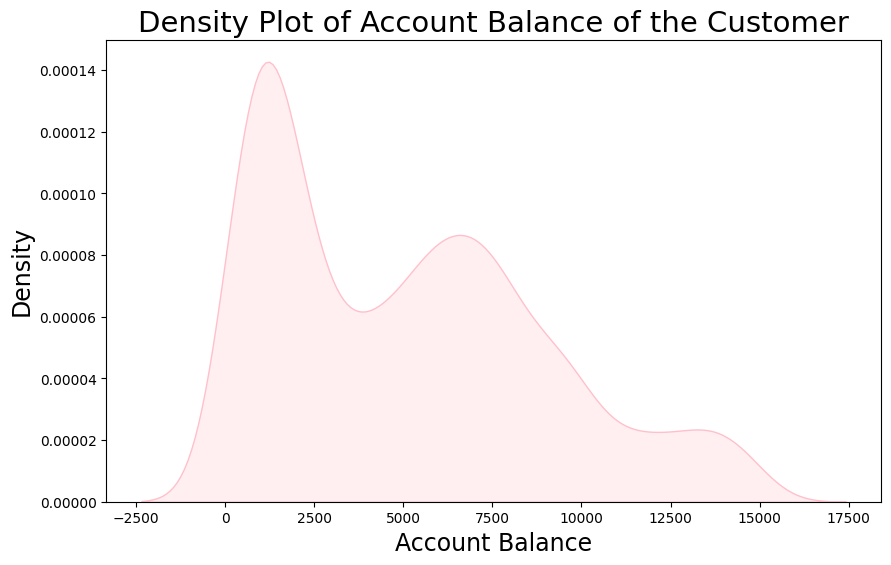

In [161]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='AccountBalance', shade=True, color='pink')
plt.xlabel('Account Balance', fontsize=17)
plt.ylabel('Density', fontsize=17)
plt.title('Density Plot of Account Balance of the Customer', fontsize=21)
plt.show()

Plot distribusi di atas menunjukkan sebaran saldo akun pelanggan setelah transaksi. Terlihat bahwa sebagian besar pelanggan memiliki saldo di kisaran **0 hingga 3.000**, yang ditandai dengan puncak densitas tertinggi di rentang tersebut. Terdapat juga puncak sekunder di sekitar **6.000–7.000**, yang mengindikasikan adanya kelompok pelanggan dengan saldo lebih tinggi. Meskipun jumlahnya kecil, ada pula pelanggan dengan saldo yang sangat tinggi (hingga 17.000) serta saldo negatif (di bawah 0), yang dapat menunjukkan cerukan (*overdraft*) atau indikasi risiko keuangan. Pola ini memberikan gambaran penting terkait profil risiko nasabah dan dapat dimanfaatkan dalam pengembangan model prediktif untuk manajemen risiko serta deteksi anomali transaksi.

## Bivariate Analysis

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


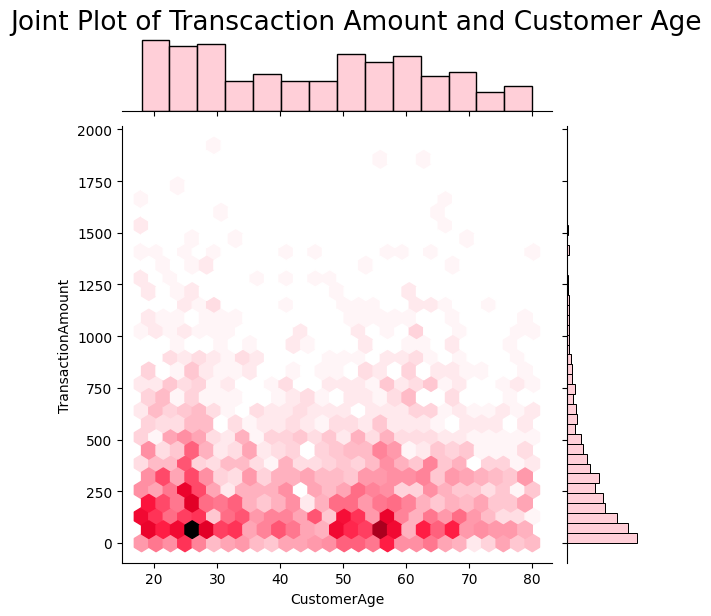

In [162]:
sns.jointplot(x='CustomerAge', y='TransactionAmount', data=df, kind='hex', color='pink')
plt.suptitle('Joint Plot of Transcaction Amount and Customer Age', y=1.02, fontsize=19)
plt.show()

Plot gabungan di atas menggambarkan hubungan antara usia pelanggan dan jumlah transaksi yang dilakukan. Terlihat bahwa sebagian besar transaksi berjumlah kecil (di bawah 500 satuan mata uang) terjadi pada rentang usia **20 hingga 40 tahun**, dengan kepadatan tertinggi di usia sekitar **25 tahun**. Transaksi bernilai besar (> 1000) muncul secara sporadis di seluruh rentang usia, tanpa konsentrasi yang signifikan pada kelompok usia tertentu. Hal ini mengindikasikan bahwa meskipun kelompok usia muda mendominasi dari segi frekuensi, transaksi besar dilakukan oleh berbagai kelompok usia secara merata. Pola ini bermanfaat dalam segmentasi pelanggan berdasarkan perilaku transaksi dan dapat digunakan untuk menyesuaikan strategi deteksi anomali berdasarkan demografi.

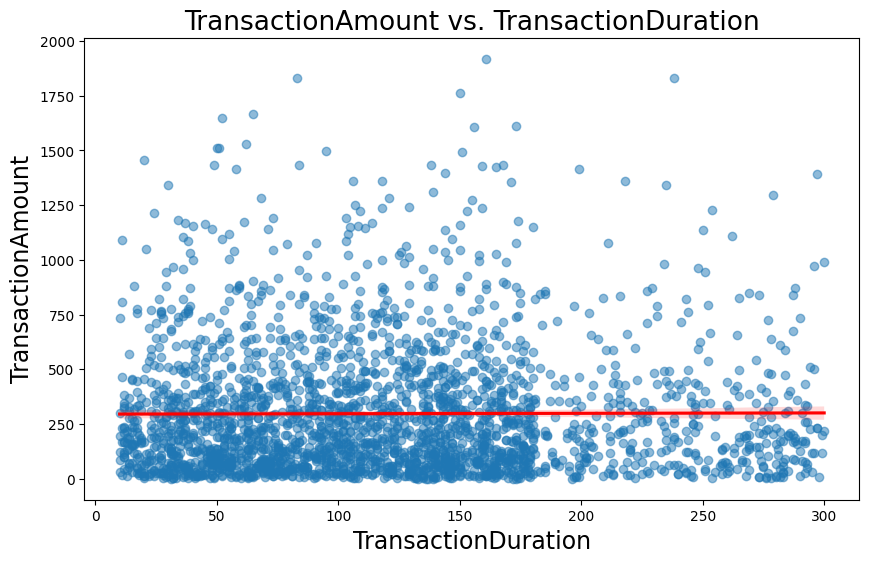

In [163]:
plt.figure(figsize=(10,6))
sns.regplot(x='TransactionDuration', y='TransactionAmount', data=df, scatter_kws={'alpha':0.5}, line_kws = {'color':'red'})
plt.title('TransactionAmount vs. TransactionDuration', fontsize=19)
plt.xlabel('TransactionDuration', fontsize=17)
plt.ylabel('TransactionAmount', fontsize=17)
plt.show()

Scatter plot di atas memperlihatkan hubungan antara durasi transaksi (dalam detik) dan jumlah nominal transaksi. Titik-titik data tersebar cukup luas, namun tidak menunjukkan pola hubungan yang jelas antara kedua variabel tersebut. Garis regresi linier yang hampir datar menunjukkan bahwa **durasi transaksi tidak memiliki korelasi yang signifikan terhadap jumlah transaksi**. Sebagian besar transaksi terjadi dalam durasi di bawah 100 detik dan berada di kisaran nilai nominal rendah hingga menengah (< 500). Hal ini mengindikasikan bahwa baik transaksi kecil maupun besar dapat dilakukan dalam waktu singkat, dan lama waktu proses transaksi tidak secara langsung mencerminkan besar kecilnya nilai transaksi. Namun, transaksi berdurasi sangat panjang tetap perlu diperhatikan sebagai potensi anomali.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 800x600 with 0 Axes>

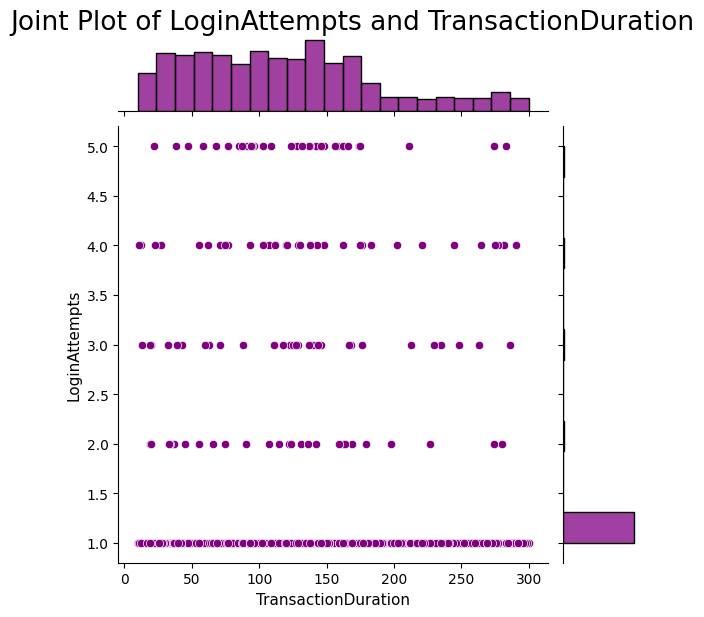

In [164]:
plt.figure(figsize=(8,6))
sns.jointplot(y='LoginAttempts', x='TransactionDuration', data=df, color='purple')
plt.xlabel('TransactionDuration', fontsize=11)
plt.ylabel('LoginAttempts', fontsize=11)
plt.suptitle('Joint Plot of LoginAttempts and TransactionDuration', y=1.02, fontsize=19)
plt.show()

Visualisasi di atas menunjukkan hubungan antara jumlah percobaan login (*LoginAttempts*) dan durasi transaksi (*TransactionDuration*). Mayoritas transaksi dilakukan hanya setelah **1 kali percobaan login**, ditunjukkan oleh konsentrasi titik yang sangat tinggi pada nilai login attempt = 1. Seiring bertambahnya jumlah percobaan login (hingga 5), jumlah transaksi yang terjadi semakin sedikit. Durasi transaksi cenderung bervariasi dan tidak menunjukkan pola khusus terhadap jumlah percobaan login, meskipun terdapat beberapa titik dengan durasi tinggi setelah banyak percobaan login. Hal ini mengindikasikan bahwa transaksi yang memerlukan banyak upaya login berpotensi sebagai **indikator anomali atau risiko keamanan**, terutama bila dikombinasikan dengan durasi transaksi yang tidak biasa. Analisis lanjutan dapat difokuskan pada pola tersebut untuk mendeteksi potensi penipuan.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 1000x600 with 0 Axes>

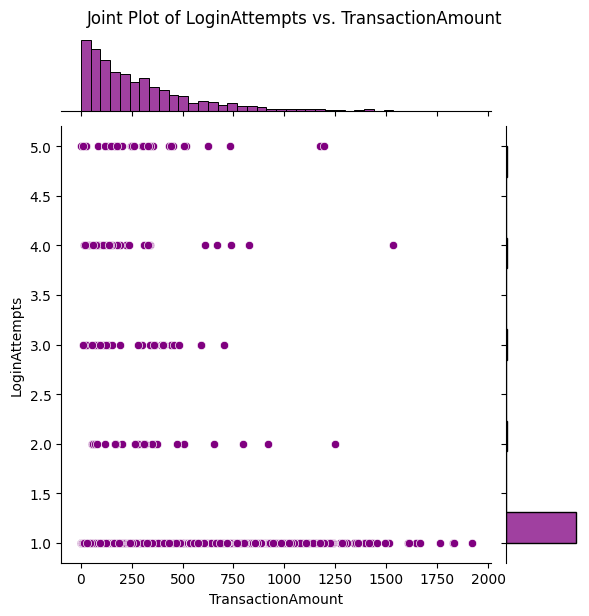

In [165]:
plt.figure(figsize=(10,6))
sns.jointplot(x='TransactionAmount', y='LoginAttempts', data=df, color='purple')
plt.suptitle('Joint Plot of LoginAttempts vs. TransactionAmount', y=1.02)
plt.show()

Plot di atas menunjukkan hubungan antara jumlah percobaan login (*LoginAttempts*) dan nilai transaksi (*TransactionAmount*). Sebagian besar transaksi terjadi hanya setelah **1 kali login**, dengan sebaran nilai transaksi yang bervariasi, tetapi sebagian besar tetap berada di bawah 500 satuan mata uang. Untuk transaksi yang memerlukan lebih dari satu kali login (2–5 kali), jumlahnya semakin sedikit, namun masih mencakup transaksi bernilai besar secara sporadis, termasuk transaksi di atas 1.000.

Temuan ini mengindikasikan bahwa **nilai transaksi tidak secara langsung berkorelasi dengan jumlah login**, namun kombinasi antara **nilai transaksi yang tinggi dan percobaan login yang banyak** dapat menjadi sinyal anomali yang patut ditelusuri lebih lanjut, khususnya dalam konteks pencegahan penipuan. Insight ini bisa dimanfaatkan dalam pembangunan sistem peringatan dini untuk mendeteksi transaksi mencurigakan.

## Multivariate

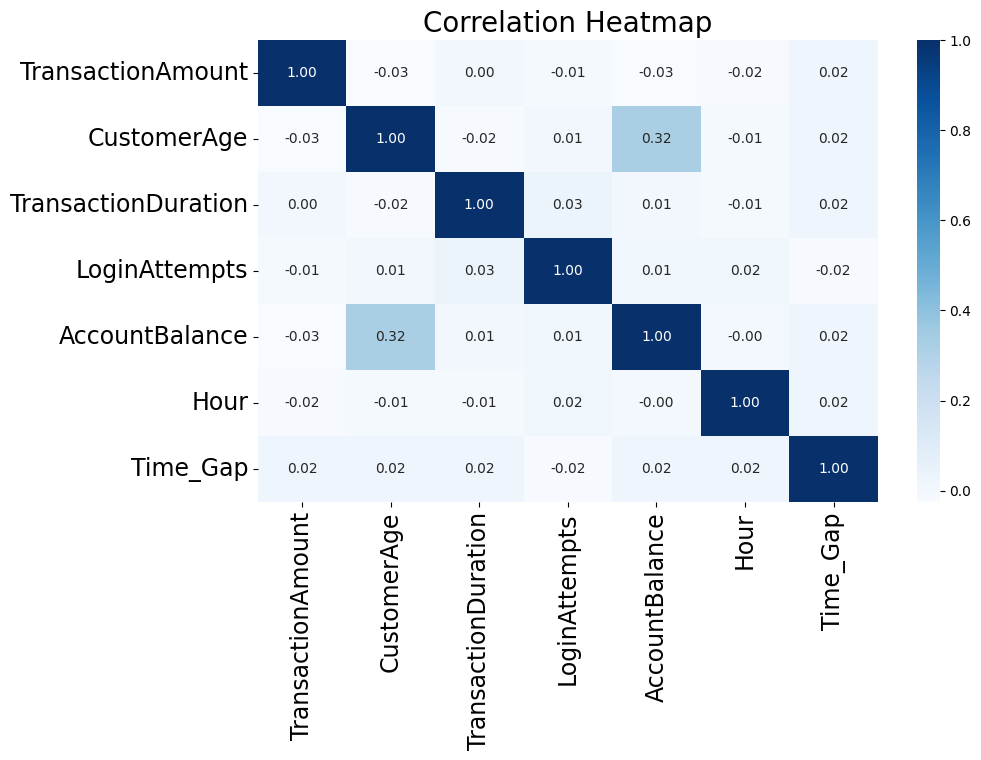

In [166]:
plt.figure(figsize=(10,6))

numeric_columns = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.xticks(rotation=90, fontsize=17)
plt.yticks(fontsize=17)
plt.title('Correlation Heatmap', fontsize=20)
plt.show()

Heatmap di atas menunjukkan matriks korelasi antara berbagai variabel numerik dalam dataset. Mayoritas pasangan variabel menunjukkan nilai korelasi yang sangat rendah (mendekati nol), yang mengindikasikan **hubungan linier yang lemah atau tidak signifikan** di antara mereka. Satu-satunya korelasi yang relatif menonjol adalah antara **CustomerAge dan AccountBalance** (nilai korelasi ≈ 0.32), yang berarti semakin tua usia pelanggan, cenderung memiliki saldo akun yang lebih tinggi—kemungkinan mencerminkan kestabilan finansial yang meningkat seiring bertambahnya usia.

Tidak terdapat hubungan korelasi yang signifikan antara **TransactionAmount** dengan variabel lain, termasuk **LoginAttempts**, **TransactionDuration**, maupun **Hour**, yang mengindikasikan bahwa perilaku transaksi tidak mudah diprediksi hanya berdasarkan karakteristik waktu atau login.

Secara keseluruhan, rendahnya korelasi ini menunjukkan bahwa untuk membangun model prediktif yang baik (misalnya deteksi fraud), **dibutuhkan pendekatan non-linear atau multivariabel**, karena pola hubungan antar fitur tidak bersifat linier secara sederhana.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

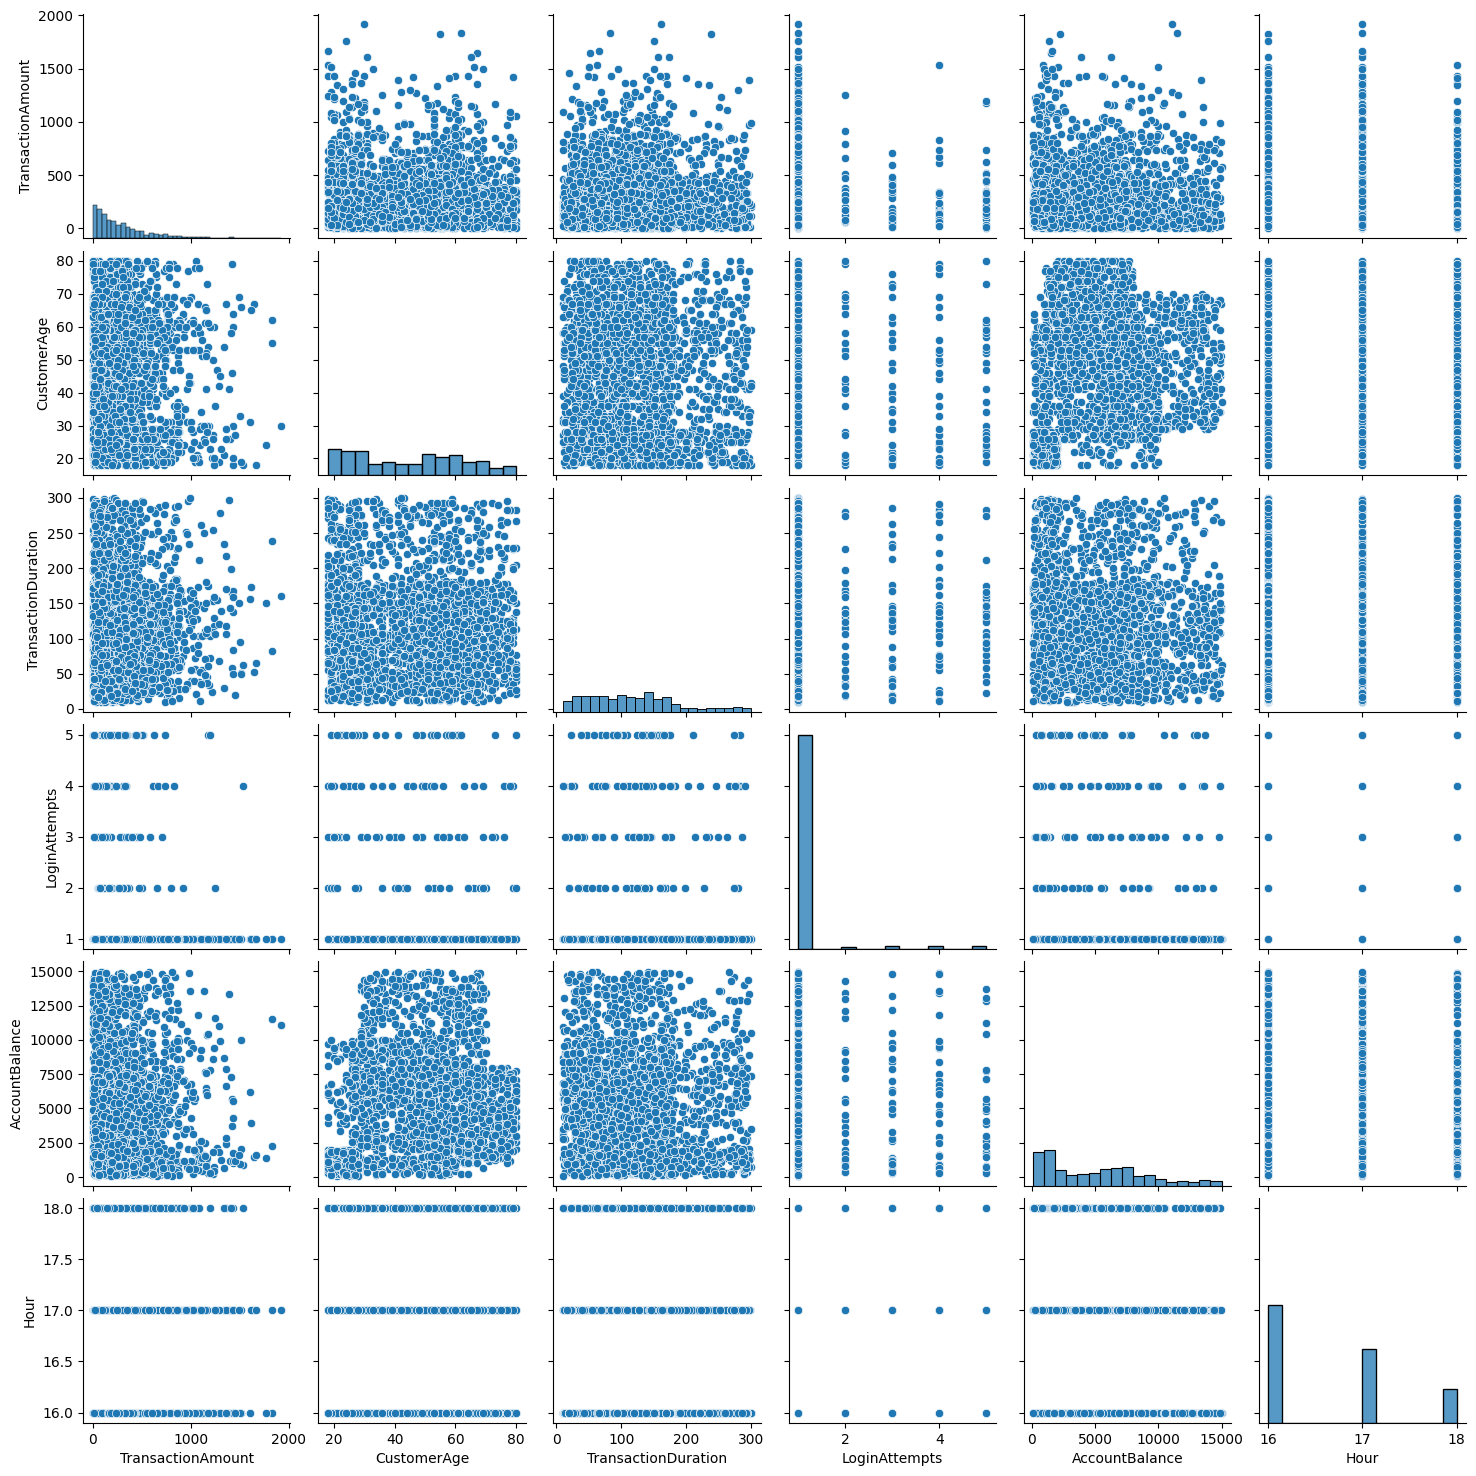

In [167]:
sns.pairplot(df)

Pairplot di atas menyajikan hubungan visual antara semua kombinasi pasangan variabel numerik dalam dataset. Beberapa pola penting yang dapat diamati:

- Sebagian besar hubungan antar variabel menunjukkan **sebaran acak tanpa pola linier yang kuat**, menguatkan hasil dari korelasi heatmap sebelumnya.
- **TransactionAmount**, **TransactionDuration**, dan **AccountBalance** memiliki distribusi yang sangat menyebar (terlihat dari sebaran titik yang luas), namun tetap cenderung terkonsentrasi di nilai-nilai rendah.
- **LoginAttempts** dan **Hour** bersifat kategorikal/discrete, sehingga scatter plot-nya berbentuk strip dengan titik-titik yang berada di level tetap (1–5 untuk login, 16–18 untuk jam).
- Distribusi univariat pada diagonal menunjukkan bahwa sebagian besar variabel memiliki **distribusi skewed**, khususnya *TransactionAmount*, *AccountBalance*, dan *TransactionDuration*, yang terpusat di nilai-nilai kecil dan menurun tajam di ekor kanan.
- Tidak tampak adanya **cluster yang jelas** antar pasangan variabel, sehingga pemisahan segmen pengguna atau deteksi outlier mungkin memerlukan teknik visualisasi tambahan seperti PCA atau t-SNE.

Secara keseluruhan, pairplot ini mendukung temuan bahwa sebagian besar hubungan antar variabel bersifat non-linier dan lemah secara korelasi, sehingga metode eksplorasi lanjutan atau machine learning berbasis non-linier akan lebih cocok untuk analisis lebih lanjut seperti segmentasi atau prediksi fraud.

# **5. Data Preprocessing**

## Missing Value Analysis

In [168]:
df.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
TransactionDay             0
DayOfWeek                  0
Hour                       0
Time_Gap                   0
dtype: int64

Tidak terdapat missing value pada data yang digunakan.

## Cek duplikasi data

In [169]:
df.duplicated().sum()

0

Tidak terdapat duplikasi data

## Outlier Analysis

In [170]:
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers

numerical_features = df.select_dtypes(include=np.number).columns

for feature in numerical_features:
    outliers = detect_outliers_iqr(df[feature])
    if outliers.sum() > 0:
        print(f"Outliers detected in {feature}:")
        print(df[outliers][[feature]])  
        print("\n")  

Outliers detected in TransactionAmount:
      TransactionAmount
74              1212.51
82               922.55
85              1340.19
110             1045.22
129             1036.66
...                 ...
2401             953.17
2403            1493.00
2414            1664.33
2428             981.90
2436             942.70

[113 rows x 1 columns]


Outliers detected in LoginAttempts:
      LoginAttempts
23                3
26                5
32                3
38                2
61                2
...             ...
2423              4
2445              3
2455              2
2457              2
2492              2

[122 rows x 1 columns]




Terlalu banyak outlier pada data yang digunakan. Dikhawatirkan terdapat informasi penting yang terlewat, maka outlier akan tetap digunakan dan ditangani dengan data scaling.

## Feature Engineering

Pada tahap ini akan dilakukan binning untuk variabel LoginAttempts

In [171]:
bins = [0, 1, 3, 5, float('inf')]
labels = ['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi']
df['LoginAttempts_Binned'] = pd.cut(df['LoginAttempts'], bins=bins, labels=labels, right=True)
df['LoginAttempts_Binned'] = df['LoginAttempts_Binned'].astype('object')
print(df[['LoginAttempts', 'LoginAttempts_Binned']].head())

   LoginAttempts LoginAttempts_Binned
0              1        Sangat Rendah
1              1        Sangat Rendah
2              1        Sangat Rendah
3              1        Sangat Rendah
4              1        Sangat Rendah


## Drop Variabel yang Tidak Diperlukan

Karena akan dilakukan clustering non time series, maka variabel yang mewakili keterangan waktu akan dihapus dari data.

In [172]:
df = df.drop(columns=['AccountID', 'TransactionID', 'DeviceID', 'IP Address', 'Time_Gap','TransactionDay', 'PreviousTransactionDate', 'TransactionDate', 'Hour', 'DayOfWeek'])

In [173]:
df1 = df.copy()

## Pre-Processing Kolom Numerik dengan Scaling dan Kolom Kategorik dengan Encoding

In [174]:
categorical_columns = df.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), df.select_dtypes(exclude=['object']).columns),  
        ('cat', OneHotEncoder(sparse_output=False), categorical_columns)
    ])

## Feature Extraction

In [175]:
pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA())
])
pca_pipeline.fit(df)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['TransactionAmount', 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  Index(['TransactionType', 'Location', 'MerchantID', 'Channel',
       'CustomerOccupation', 'LoginAttempts_Binned'],
      dtype='object'))])),
                ('pca', PCA())])

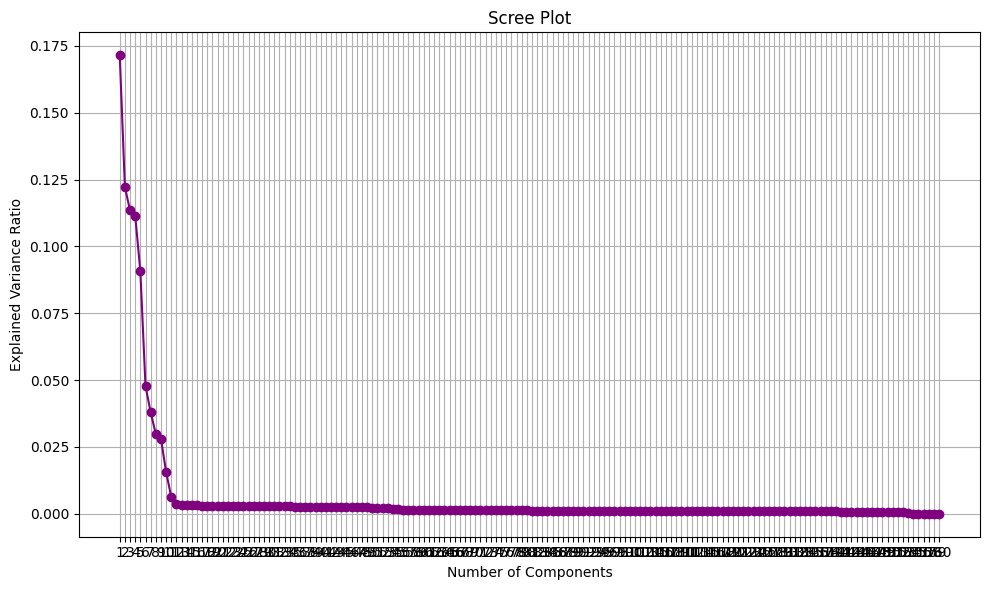

In [176]:
pca = pca_pipeline.named_steps['pca']
explained_var = pca.explained_variance_ratio_
components = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(10,6))
plt.plot(components, explained_var, marker='o', linestyle='-', color='purple', label='Individual Explained Variance')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(components)  
plt.grid(True)
plt.tight_layout()
plt.show()

Akan diambil beberapa komponen hingga diperoleh explained variance setidaknya sebesar 60%

In [177]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_60 = np.argmax(cumulative_variance >= 0.6) + 1
print(f"Number of components to explain at least 60% of the variance: {n_components_60}")

Number of components to explain at least 60% of the variance: 5


In [178]:
n_components = 20 

pca_pipeline.set_params(pca__n_components=n_components)
pca_result = pca_pipeline.transform(df)

# **6. Pembangunan Model Clustering**

Untuk mengelompokkan pola perilaku pelanggan berdasarkan data transaksi, dilakukan penerapan beberapa metode *unsupervised learning*, yaitu **K-Means Clustering**, **Agglomerative Clustering**, dan **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**. Tujuan dari clustering ini adalah untuk mengidentifikasi segmen-segmen pengguna yang memiliki karakteristik transaksi serupa tanpa menggunakan label atau informasi hasil sebelumnya.

Evaluasi performa dari masing-masing metode clustering dilakukan dengan menggunakan **Silhouette Score**, yang mengukur seberapa baik suatu titik data cocok dengan klusternya sendiri dibandingkan dengan kluster lainnya. Nilai Silhouette yang mendekati +1 menunjukkan pemisahan kluster yang baik, sedangkan nilai mendekati 0 atau negatif mengindikasikan tumpang tindih antar kluster.

- **K-Means** dan **Agglomerative Clustering** diuji pada jumlah kluster yang bervariasi, dari 2 hingga 10.
- **DBSCAN** dieksplorasi dengan rentang nilai parameter epsilon (`eps`) untuk menentukan radius pencarian tetangga, serta `min_samples` yang mengatur jumlah minimum titik dalam satu area agar dianggap sebagai kluster.

Langkah ini diawali dengan reduksi dimensi menggunakan PCA agar visualisasi dan komputasi clustering menjadi lebih efisien serta menghindari curse of dimensionality. Hasil evaluasi akan digunakan untuk memilih metode clustering terbaik yang memberikan pemisahan kluster paling optimal.


## **a. Pembangunan Model Clustering**

In [179]:
silhouette_scores_kmeans = []
silhouette_scores_agglomerative = []
silhouette_scores_dbscan = []

range_n_clusters = list(range(2, 11)) 

# K-Means Clustering
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, cluster_labels)
    silhouette_scores_kmeans.append(score)

# Agglomerative Clustering
for n_clusters in range_n_clusters:
    agglomerative = AgglomerativeClustering(n_clusters=n_clusters)
    cluster_labels = agglomerative.fit_predict(pca_result)
    score = silhouette_score(pca_result, cluster_labels)
    silhouette_scores_agglomerative.append(score)

# DBSCAN clustering (using a range of eps values and min_samples)
eps_values = np.linspace(0.1, 1.5, 15)  
min_samples = 5 

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = dbscan.fit_predict(pca_result)
    if len(np.unique(cluster_labels)) > 1:  
        score = silhouette_score(pca_result, cluster_labels)
        silhouette_scores_dbscan.append(score)
    else:
        silhouette_scores_dbscan.append(-1)  

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

In [180]:
print("Silhouette Scores for K-Means Clustering:")
print(silhouette_scores_kmeans)

print("\nSilhouette Scores for Agglomerative Clustering:")
print(silhouette_scores_agglomerative)

print("\nSilhouette Scores for DBSCAN:")
print(silhouette_scores_dbscan)

Silhouette Scores for K-Means Clustering:
[0.13537888557989758, 0.14812400796336433, 0.1388915320155243, 0.1395068978790758, 0.1326272674909321, 0.12540836795743804, 0.11192330511850658, 0.10149646118496874, 0.09908563970047989]

Silhouette Scores for Agglomerative Clustering:
[0.10834193420688913, 0.13533823169193032, 0.13701022045674643, 0.10982430076612068, 0.10772214261107041, 0.10594425817886255, 0.10635520346452951, 0.09152794046761824, 0.09538784285849815]

Silhouette Scores for DBSCAN:
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]


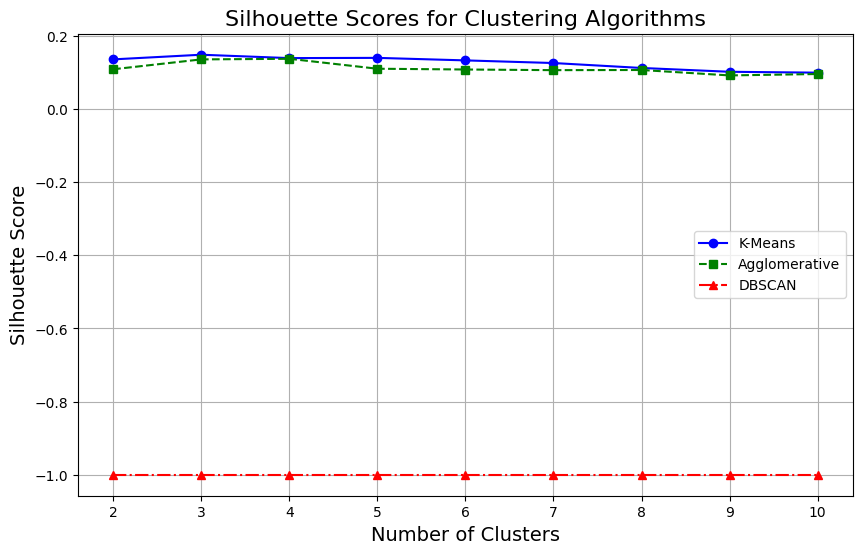

In [181]:
# Plotting the silhouette scores for each algorithm
plt.figure(figsize=(10,6))

plt.plot(range_n_clusters, silhouette_scores_kmeans, label="K-Means", marker='o', linestyle='-', color='b')
plt.plot(range_n_clusters, silhouette_scores_agglomerative, label="Agglomerative", marker='s', linestyle='--', color='g')
plt.plot(range_n_clusters, silhouette_scores_dbscan[:len(range_n_clusters)], label="DBSCAN", marker='^', linestyle='-.', color='r')

plt.title('Silhouette Scores for Clustering Algorithms', fontsize=16)
plt.xlabel('Number of Clusters', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## **b. Evaluasi Model Clustering**

Best Model: K-Means with silhouette score: 0.14812400796336433


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


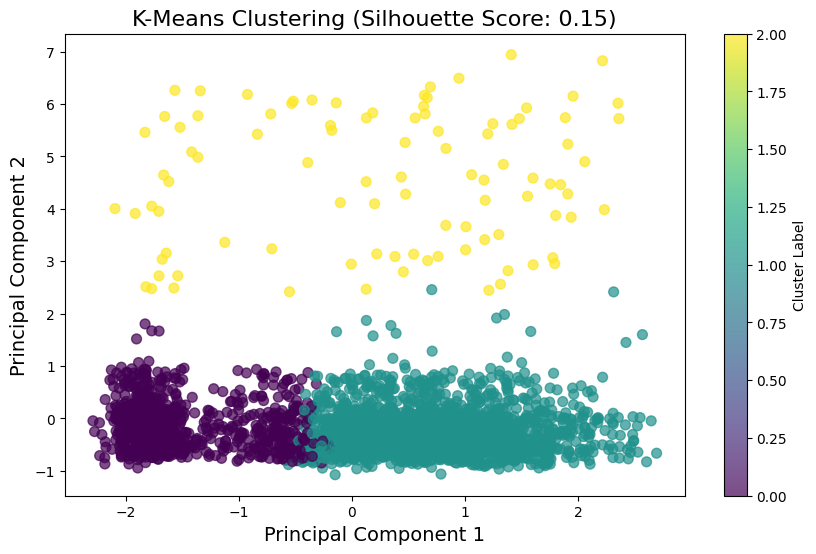

In [182]:
best_kmeans_n_clusters = silhouette_scores_kmeans.index(max(silhouette_scores_kmeans)) + 2  # +2 because range starts at 2
best_agglomerative_n_clusters = silhouette_scores_agglomerative.index(max(silhouette_scores_agglomerative)) + 2
best_dbscan_eps = silhouette_scores_dbscan.index(max(silhouette_scores_dbscan))  # DBSCAN does not use number of clusters directly

best_model = None
best_score = -1

if max(silhouette_scores_kmeans) > best_score:
    best_score = max(silhouette_scores_kmeans)
    best_model = "K-Means"
    best_n_clusters = best_kmeans_n_clusters

if max(silhouette_scores_agglomerative) > best_score:
    best_score = max(silhouette_scores_agglomerative)
    best_model = "Agglomerative"
    best_n_clusters = best_agglomerative_n_clusters

if max(silhouette_scores_dbscan) > best_score:
    best_score = max(silhouette_scores_dbscan)
    best_model = "DBSCAN"
    best_eps = best_dbscan_eps

print(f"Best Model: {best_model} with silhouette score: {best_score}")

if best_model == "K-Means":
    kmeans = KMeans(n_clusters=best_n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_result)

elif best_model == "Agglomerative":
    agglomerative = AgglomerativeClustering(n_clusters=best_n_clusters)
    cluster_labels = agglomerative.fit_predict(pca_result)

elif best_model == "DBSCAN":
    dbscan = DBSCAN(eps=best_eps, min_samples=5)
    cluster_labels = dbscan.fit_predict(pca_result)
    cluster_labels[cluster_labels == -1] = np.max(cluster_labels) + 1  

# Visualize the clusters
plt.figure(figsize=(10,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap='viridis', s=50, alpha=0.7)
plt.title(f'{best_model} Clustering (Silhouette Score: {best_score:.2f})', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.colorbar(label='Cluster Label')
plt.show()

Visualisasi di atas menunjukkan hasil **K-Means Clustering terbaik** berdasarkan eksplorasi jumlah klaster (antara 2 hingga 10) menggunakan data yang telah direduksi dimensinya melalui PCA. Model terbaik ini menghasilkan **3 klaster** dengan **nilai Silhouette Score sebesar 0.15**.

Meskipun model ini memberikan hasil pemisahan klaster yang paling optimal dibandingkan parameter lainnya, **nilai Silhouette Score masih tergolong sangat rendah**. Hal ini menunjukkan bahwa pemisahan antar klaster belum cukup baik — banyak data masih berada di dekat batas antar klaster atau tidak cocok secara konsisten dengan klusternya.

Secara visual:
- Terdapat indikasi pemisahan yang cukup baik antara klaster di sepanjang Principal Component 1, tetapi masih terdapat area tumpang tindih.
- Salah satu klaster terlihat menyebar luas, yang bisa menjadi tanda bahwa fitur-fitur yang digunakan saat ini belum cukup representatif untuk membedakan pola perilaku pelanggan secara optimal.

**Sebagai langkah selanjutnya, akan dilakukan proses feature selection untuk mengidentifikasi atribut-atribut yang paling relevan**, dengan harapan dapat meningkatkan kualitas clustering dan memperoleh segmentasi yang lebih bermakna serta terpisah dengan lebih jelas.


## **c. Feature Selection (Opsional)**

Dalam upaya meningkatkan kualitas hasil clustering, dilakukan proses **feature selection** dengan mempertimbangkan baik aspek statistik maupun domain knowledge. Variabel-variabel berikut dipilih untuk digunakan dalam pemodelan:

- **LoginAttempts**: Mewakili jumlah percobaan login sebelum transaksi berhasil. Nilai yang tinggi dapat mengindikasikan potensi anomali atau aktivitas mencurigakan.
- **TransactionType**: Menunjukkan jenis transaksi (debit/kredit), yang dapat mencerminkan pola perilaku finansial pelanggan.
- **TransactionAmount**: Merupakan fitur utama yang menunjukkan nilai transaksi. Informasi ini sangat penting karena besar kecilnya transaksi bisa menjadi indikator karakteristik pengguna atau risiko.
- **LoginAttempts_Binned**: Merupakan versi kategorikal dari `LoginAttempts` yang telah dibagi ke dalam beberapa rentang. Fitur ini membantu model untuk menangkap variasi non-linier yang mungkin tidak ditangkap oleh nilai aslinya secara langsung.

Pemilihan fitur ini bertujuan untuk **menyederhanakan model namun tetap mempertahankan fitur-fitur yang dianggap memiliki pengaruh paling relevan terhadap perilaku transaksi**. Selain itu, variabel-variabel tersebut dipilih karena memiliki potensi untuk meningkatkan separabilitas klaster dan memberikan interpretasi yang lebih bermakna dari hasil clustering.


In [183]:
X = df[['LoginAttempts', 'TransactionType', 'TransactionAmount', 'LoginAttempts_Binned']]

In [184]:
X

,LoginAttempts,TransactionType,TransactionAmount,LoginAttempts_Binned
0,1,Debit,14.09,Sangat Rendah
1,1,Debit,376.24,Sangat Rendah
2,1,Debit,126.29,Sangat Rendah
3,1,Debit,184.50,Sangat Rendah
4,1,Credit,13.45,Sangat Rendah
...,...,...,...,...
2507,1,Credit,856.21,Sangat Rendah
2508,1,Debit,251.54,Sangat Rendah
2509,1,Debit,28.63,Sangat Rendah
2510,1,Debit,185.97,Sangat Rendah


In [185]:
categorical_columns = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X.select_dtypes(exclude=['object']).columns),
        ('cat', OneHotEncoder(sparse_output=False), categorical_columns) 
    ])

pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA())
])

pca_pipeline.fit(X)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['LoginAttempts', 'TransactionAmount'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  Index(['TransactionType', 'LoginAttempts_Binned'], dtype='object'))])),
                ('pca', PCA())])

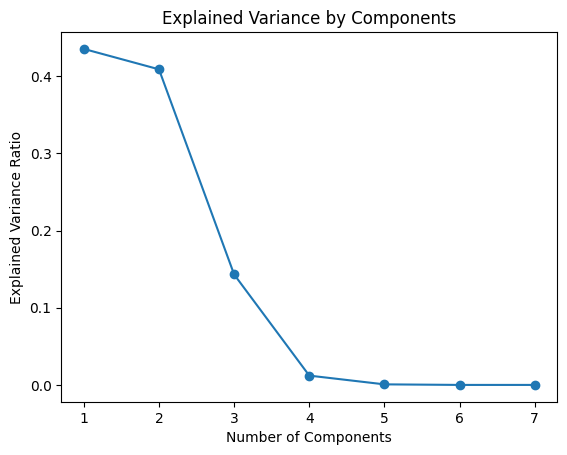

In [186]:
pca = pca_pipeline.named_steps['pca']
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

Grafik di atas menunjukkan **rasio variansi yang dijelaskan oleh masing-masing komponen utama** (Principal Component) pada proses Principal Component Analysis (PCA). Terlihat bahwa:

- Komponen ke-1 dan ke-2 menjelaskan sebagian besar variansi data (masing-masing sekitar 44% dan 41%).
- Komponen ke-3 masih menyumbang sekitar 14% variansi.
- Setelah komponen ke-3, sumbangan variansi dari setiap komponen berikutnya turun drastis hingga mendekati nol.

Berdasarkan pola ini, diputuskan untuk menggunakan **3 komponen utama** karena:
- Ketiga komponen tersebut secara kumulatif menjelaskan hampir **100% variansi data** yang berarti representasi data tetap terjaga dengan baik.
- Penambahan komponen ke-4 dan seterusnya memberikan kontribusi yang sangat kecil dan tidak signifikan terhadap informasi yang ditangkap.
- Pemilihan 3 komponen ini juga mempertimbangkan prinsip *elbow method*, di mana terjadi pelandaian kurva setelah titik ke-3.

Dengan demikian, **3 komponen PCA dianggap optimal** untuk mereduksi dimensi data tanpa kehilangan informasi penting, sekaligus meningkatkan efisiensi dan efektivitas dalam proses clustering.

In [187]:
n_components = 3 

pca_pipeline.set_params(pca__n_components=n_components)
pca_result = pca_pipeline.transform(X)

silhouette_scores = []
range_n_clusters = list(range(2, 11))  
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, cluster_labels)
    silhouette_scores.append(score)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

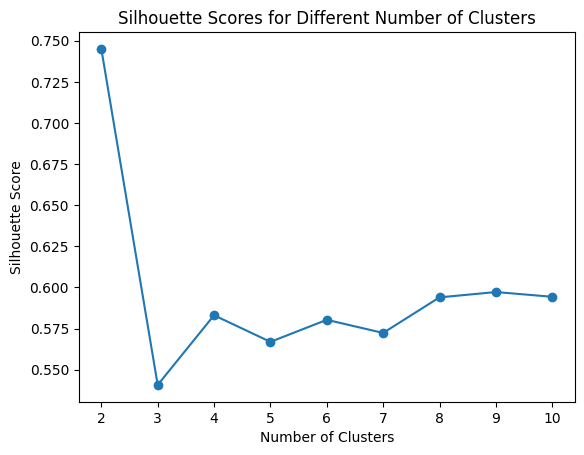

In [188]:
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

Setelah dilakukan pemilihan fitur berdasarkan relevansi terhadap perilaku transaksi, yaitu dengan menggunakan variabel `LoginAttempts`, `TransactionType`, `TransactionAmount`, dan `LoginAttempts_Binned`, terjadi **peningkatan drastis pada hasil clustering**.

Grafik di atas menunjukkan nilai **Silhouette Score** untuk berbagai jumlah klaster menggunakan metode K-Means setelah feature selection dilakukan. Terlihat bahwa nilai Silhouette Score tertinggi dicapai saat jumlah klaster = 2, yaitu sekitar **0.74**, yang merupakan peningkatan signifikan dibandingkan sebelumnya (hanya sekitar 0.15).

In [189]:
optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_n_clusters}")

Optimal number of clusters based on silhouette score: 2


In [190]:
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(pca_result)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## **d. Visualisasi Hasil Clustering**

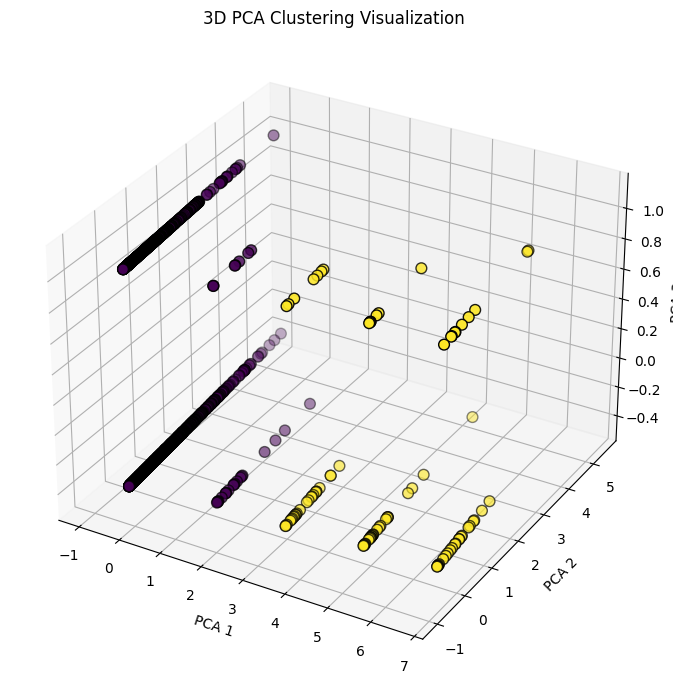

In [191]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_result[:, 0], 
    pca_result[:, 1], 
    pca_result[:, 2], 
    c=cluster_labels, 
    cmap='viridis', 
    edgecolor='k', 
    s=60
)

ax.set_title('3D PCA Clustering Visualization')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
plt.tight_layout()
plt.show()

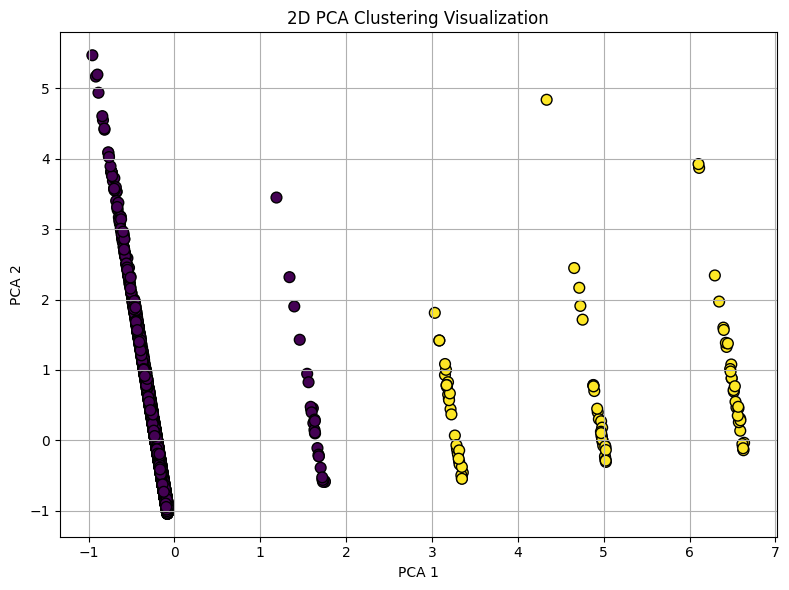

In [192]:
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0], 
    pca_result[:, 1], 
    c=cluster_labels, 
    cmap='viridis', 
    edgecolor='k', 
    s=60
)
plt.title('2D PCA Clustering Visualization')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.tight_layout()
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

In [193]:
df1['cluster'] = cluster_labels

In [194]:
profile = df1.groupby('cluster').describe()
profile.to_excel('profiling.xlsx')
profile

TransactionAmount                                                \
                    count        mean         std   min     25%     50%   
cluster                                                                   
0                  2417.0  298.429772  292.677029  0.26  81.270  211.69   
1                    95.0  276.324316  273.282522  1.93  89.785  180.65   

                          CustomerAge             ... LoginAttempts       \
             75%      max       count       mean  ...           75%  max   
cluster                                           ...                      
0        415.880  1919.11      2417.0  44.679355  ...           1.0  2.0   
1        380.145  1531.31        95.0  44.536842  ...           5.0  5.0   

        AccountBalance                                                       \
                 count         mean          std     min       25%      50%   
cluster                                                                       
0               2417.0  5100.650790  3886.581796  101.25  1504.640  4732.57   
1                 95.0  5461.643053  4257.569517  271.78  1493.585  4976.18   

                             
              75%       max  
cluster                      
0        7643.660  14977.99  
1        8369.695  14851.28  

[2 rows x 40 columns]

In [195]:
login_attempts_counts = df1.groupby('cluster')['LoginAttempts'].value_counts().unstack(fill_value=0)
print(login_attempts_counts)

LoginAttempts     1   2   3   4   5
cluster                            
0              2390  27   0   0   0
1                 0   0  31  32  32


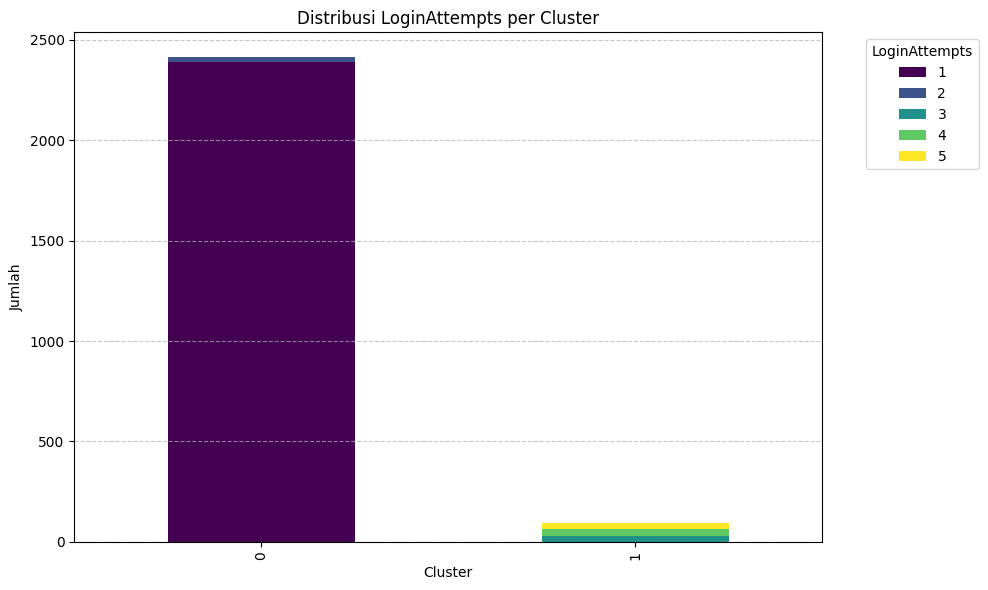

In [196]:
# Bar chart
login_attempts_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Distribusi LoginAttempts per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah')
plt.legend(title='LoginAttempts', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

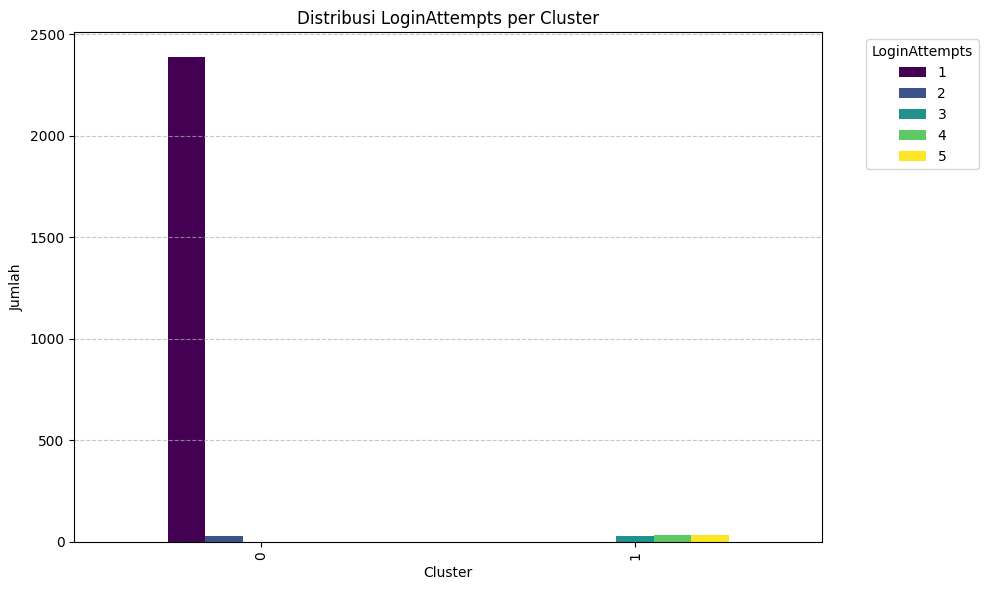

In [197]:
login_attempts_counts.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='viridis')

plt.title('Distribusi LoginAttempts per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah')
plt.legend(title='LoginAttempts', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Grafik di atas menunjukkan distribusi jumlah percobaan login (`LoginAttempts`) di setiap klaster hasil clustering. Terlihat dua klaster utama: **Cluster 0** dan **Cluster 1**, dengan karakteristik sebagai berikut:

- **Cluster 0** didominasi secara ekstrem oleh transaksi yang hanya membutuhkan **1 kali percobaan login**, dengan jumlah yang jauh melebihi kombinasi lainnya. Hal ini menunjukkan bahwa klaster ini mewakili pengguna dengan pola **login yang normal dan efisien**, yang kemungkinan besar merupakan transaksi sah atau reguler.

- **Cluster 1**, sebaliknya, terdiri dari transaksi yang lebih bervariasi, terutama pada `LoginAttempts` ≥ 3. Jumlahnya jauh lebih sedikit dibanding Cluster 0, namun distribusinya menunjukkan kecenderungan adanya **banyak percobaan login**, yang bisa menjadi indikator **potensi aktivitas mencurigakan atau tidak biasa**.

Dengan demikian, **Cluster 1 patut dianalisis lebih lanjut** karena bisa saja berisi transaksi yang lebih berisiko atau anomali, sementara Cluster 0 tampaknya merepresentasikan sebagian besar transaksi yang aman atau tipikal. Pola ini dapat dimanfaatkan untuk pengawasan keamanan, segmentasi pengguna berdasarkan risiko


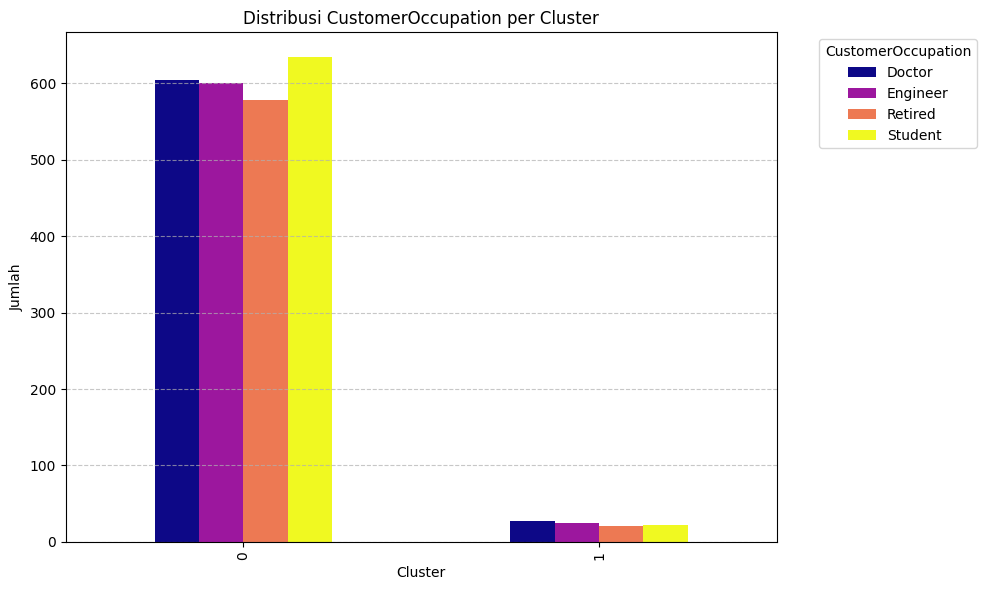

In [198]:
occupation_counts = df1.groupby('cluster')['CustomerOccupation'].value_counts().unstack(fill_value=0)

occupation_counts.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='plasma')

plt.title('Distribusi CustomerOccupation per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah')
plt.legend(title='CustomerOccupation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Grafik di atas menunjukkan distribusi pekerjaan pelanggan (`CustomerOccupation`) di masing-masing klaster hasil clustering. Dapat dilihat bahwa:

- **Cluster 0** merupakan klaster dengan jumlah pelanggan yang sangat dominan, terdiri dari seluruh kategori pekerjaan (Doctor, Engineer, Retired, dan Student) dalam jumlah besar dan relatif seimbang. Hal ini menunjukkan bahwa **Cluster 0 mencerminkan populasi mayoritas pelanggan dengan perilaku transaksi yang umum** dan tidak terlalu bervariasi berdasarkan jenis pekerjaan.

- **Cluster 1**, sebaliknya, memiliki jumlah pelanggan yang jauh lebih sedikit untuk semua kategori pekerjaan. Namun menariknya, distribusi antar pekerjaan di klaster ini tetap cukup merata. Hal ini mengindikasikan bahwa klaster ini **tidak spesifik terhadap satu jenis pekerjaan**, tetapi mungkin lebih teridentifikasi oleh pola perilaku lain (misalnya jumlah login attempts atau nilai transaksi).

Dengan kata lain, **CustomerOccupation bukanlah faktor pembeda utama antar klaster** dalam kasus ini. Sebaliknya, variabel lain seperti `LoginAttempts` tampak lebih berperan dalam membedakan karakteristik antar klaster. Meski begitu, pemeriksaan lebih lanjut bisa dilakukan untuk melihat apakah terdapat interaksi antara pekerjaan dan fitur lain dalam mendeteksi potensi risiko atau segmentasi layanan.


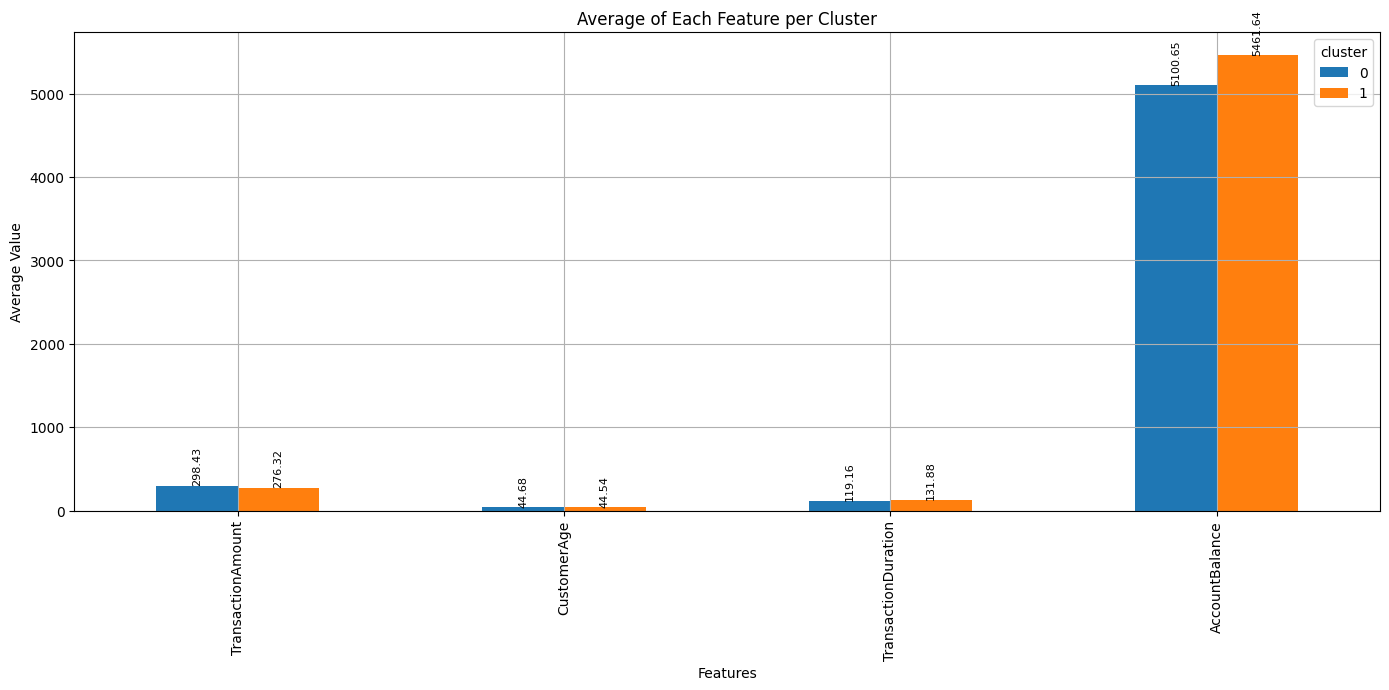

In [199]:
cluster_means = df1.groupby('cluster').mean(numeric_only=True)
cluster_means_filtered = cluster_means.drop(columns='LoginAttempts', errors='ignore')

ax = cluster_means_filtered.T.plot(kind='bar', figsize=(14, 7))
plt.title('Average of Each Feature per Cluster')
plt.xlabel('Features')
plt.ylabel('Average Value')
plt.grid(True)
plt.tight_layout()

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, rotation=90)

plt.show()

## **Analisis Karakteristik Cluster**

### Cluster 0:

- **Rata-rata Transaction Amount**: 298.43  
- **Rata-rata Customer Age**: 46.88  
- **Rata-rata Transaction Duration (detik)**: 119.16  
- **Rata-rata Account Balance**: 5106.65  
- **Dominan LoginAttempts**: 1 kali  
- **Sebaran CustomerOccupation**: Merata di semua pekerjaan (Student, Doctor, Engineer, Retired)

**Analisis:**  
Cluster ini mencerminkan mayoritas pengguna dengan perilaku transaksi yang **normal dan stabil**. Pelanggan di klaster ini cenderung:
- Melakukan transaksi dengan nominal sedang
- Usia relatif lebih tua
- Proses transaksi berlangsung cepat
- Login hanya sekali (indikasi tidak ada anomali)
- Tersebar merata dari berbagai jenis pekerjaan  

Secara keseluruhan, **Cluster 0 merepresentasikan pengguna aktif yang aman dan stabil** dalam perilaku keuangannya.

---

### Cluster 1:

- **Rata-rata Transaction Amount**: 276.32  
- **Rata-rata Customer Age**: 44.54  
- **Rata-rata Transaction Duration (detik)**: 131.88  
- **Rata-rata Account Balance**: 5461.64  
- **Dominan LoginAttempts**: ≥3 kali  
- **Sebaran CustomerOccupation**: Merata, namun jumlah total jauh lebih sedikit

**Analisis:**  
Cluster ini menunjukkan pola yang lebih **berisiko atau tidak biasa**, ditandai dengan:
- Jumlah percobaan login yang lebih tinggi, yang dapat menjadi sinyal aktivitas mencurigakan
- Durasi transaksi cenderung lebih lama
- Nilai saldo akun lebih besar meskipun nominal transaksinya sedikit lebih kecil  

Karakteristik ini mengindikasikan bahwa **Cluster 1 perlu diawasi lebih lanjut**, karena berpotensi mencakup pengguna dengan perilaku anomali, fraud, atau penggunaan tidak lazim.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [200]:
df1.to_csv('clustered_data.csv', index=False)